In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np

# Load the SCIN labels dataset
scin_df = pd.read_csv('data/scin/dataset/scin_labels.csv')
print(f"Dataset shape: {scin_df.shape}")
print(f"Columns: {list(scin_df.columns)}")
scin_df.head()


Dataset shape: (5033, 17)
Columns: ['case_id', 'dermatologist_gradable_for_skin_condition_1', 'dermatologist_gradable_for_skin_condition_2', 'dermatologist_gradable_for_skin_condition_3', 'dermatologist_skin_condition_on_label_name', 'dermatologist_skin_condition_confidence', 'weighted_skin_condition_label', 'dermatologist_gradable_for_fitzpatrick_skin_type_1', 'dermatologist_gradable_for_fitzpatrick_skin_type_2', 'dermatologist_gradable_for_fitzpatrick_skin_type_3', 'dermatologist_fitzpatrick_skin_type_label_1', 'dermatologist_fitzpatrick_skin_type_label_2', 'dermatologist_fitzpatrick_skin_type_label_3', 'gradable_for_monk_skin_tone_india', 'gradable_for_monk_skin_tone_us', 'monk_skin_tone_label_india', 'monk_skin_tone_label_us']


,case_id,dermatologist_gradable_for_skin_condition_1,dermatologist_gradable_for_skin_condition_2,dermatologist_gradable_for_skin_condition_3,dermatologist_skin_condition_on_label_name,dermatologist_skin_condition_confidence,weighted_skin_condition_label,dermatologist_gradable_for_fitzpatrick_skin_type_1,dermatologist_gradable_for_fitzpatrick_skin_type_2,dermatologist_gradable_for_fitzpatrick_skin_type_3,dermatologist_fitzpatrick_skin_type_label_1,dermatologist_fitzpatrick_skin_type_label_2,dermatologist_fitzpatrick_skin_type_label_3,gradable_for_monk_skin_tone_india,gradable_for_monk_skin_tone_us,monk_skin_tone_label_india,monk_skin_tone_label_us
0,-1000600354148496558,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Inflicted skin lesions', 'Eczema', 'Irritant...","[4, 4, 3]","{'Inflicted skin lesions': 0.41, 'Eczema': 0.4...",YES,NaN,NaN,FST2,NaN,NaN,True,True,2.0,1.0
1,-1002039107727665188,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Prurigo nodularis', 'Actinic Keratosis', 'SC...","[4, 3, 4]","{'Prurigo nodularis': 0.41, 'SCC/SCCIS': 0.41,...",YES,NaN,NaN,FST1,NaN,NaN,True,True,3.0,3.0
2,-1003358831658393077,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Impetigo', 'Herpes Zoster', 'Bullous dermati...","[2, 1, 1]","{'Impetigo': 0.55, 'Herpes Zoster': 0.23, 'Bul...",YES,NaN,NaN,FST4,NaN,NaN,True,True,3.0,4.0
3,-1003826561155964328,NO_IMAGE_QUALITY_INSUFFICIENT,NaN,NaN,[],[],{},NO,NaN,NaN,NaN,NaN,NaN,True,True,2.0,4.0
4,-1003844406100696311,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Lichen planus/lichenoid eruption', 'Follicul...","[1, 1, 1]","{'Lichen planus/lichenoid eruption': 0.33, 'Fo...",YES,NaN,NaN,FST1,NaN,NaN,True,True,1.0,1.0


In [19]:
# Function to extract the most confident label
def get_most_confident_label(row):
    """
    Extract the most confident label from dermatologist annotations
    """
    try:
        # Parse the label names and confidence scores
        labels = ast.literal_eval(row['dermatologist_skin_condition_on_label_name'])
        confidences = ast.literal_eval(row['dermatologist_skin_condition_confidence'])
        
        # Skip if empty
        if not labels or not confidences:
            return None
            
        # Find the index of the highest confidence
        max_conf_idx = np.argmax(confidences)
        
        # Return the label with highest confidence
        return labels[max_conf_idx]
        
    except (ValueError, SyntaxError, TypeError):
        return None

# Apply the function to get most confident labels
scin_df['most_confident_label'] = scin_df.apply(get_most_confident_label, axis=1)

# Remove rows where we couldn't extract a label
scin_df_with_labels = scin_df.dropna(subset=['most_confident_label'])

print(f"Total rows: {len(scin_df)}")
print(f"Rows with valid labels: {len(scin_df_with_labels)}")
print(f"Percentage with valid labels: {len(scin_df_with_labels)/len(scin_df)*100:.1f}%")


Total rows: 5033
Rows with valid labels: 3061
Percentage with valid labels: 60.8%


Total number of samples: 3061
Mean samples per label: 14.58
Label with most samples: 'Eczema' with 474 samples
Label with least samples: 'Chicken pox exanthem' with 1 samples

Quartile values for label counts:
Q1 (25th percentile): 1.0
Q2 (median/50th percentile): 2.0
Q3 (75th percentile): 7.75

Number of labels per quartile:
Labels with <= Q1 samples (1): 85
Labels with > Q1 and <= Q2 samples (1-2): 34
Labels with > Q2 and <= Q3 samples (2-8): 38
Labels with > Q3 samples (8+): 53

--- Most Confident Label distribution table ---
most_confident_label
Eczema                                                                        474
Allergic Contact Dermatitis                                                   254
Urticaria                                                                     214
Insect Bite                                                                   181
Folliculitis                                                                  140
Psoriasis                         

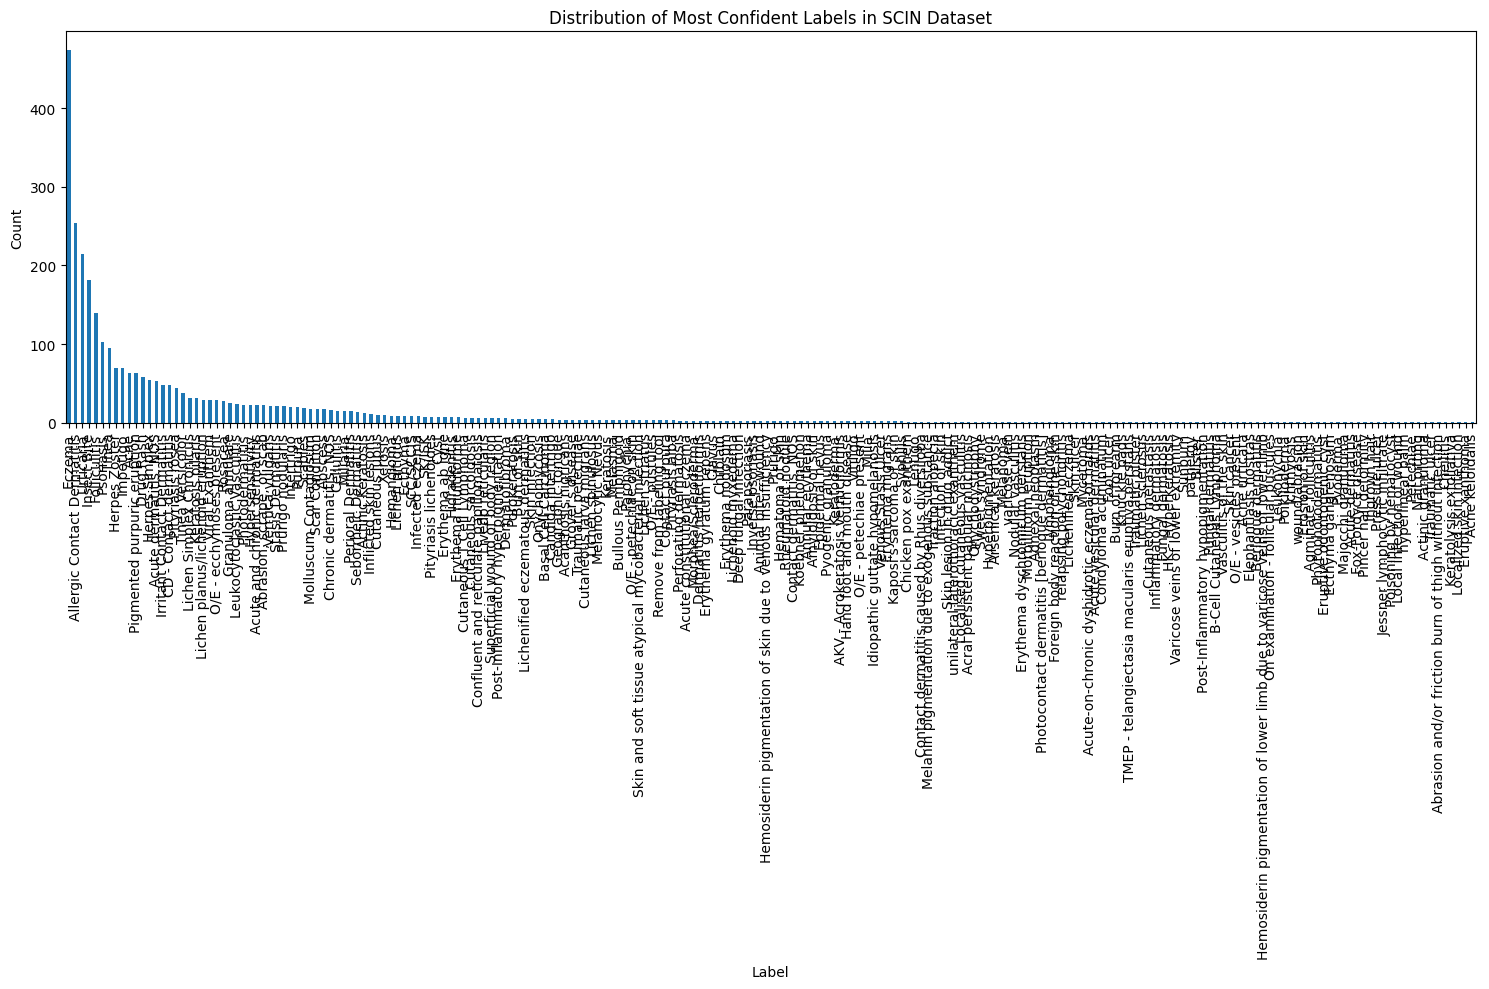

In [20]:
# Analysis of SCIN dataset - Most confident labels
import pandas as pd
import matplotlib.pyplot as plt

# Count the occurrences of each most confident label
scin_label_counts = scin_df_with_labels['most_confident_label'].value_counts()

# --- statistical analysis ---

# Total number of samples (rows with valid labels)
total_samples_scin = scin_df_with_labels.shape[0]
print(f"Total number of samples: {total_samples_scin}")

# Mean number of samples per label
mean_samples_per_label = scin_label_counts.mean()
print(f"Mean samples per label: {mean_samples_per_label:.2f}")

# Label with most samples
most_samples_label = scin_label_counts.idxmax()
most_samples_count = scin_label_counts.max()
print(f"Label with most samples: '{most_samples_label}' with {most_samples_count} samples")

# Label with least samples
least_samples_label = scin_label_counts.idxmin()
least_samples_count = scin_label_counts.min()
print(f"Label with least samples: '{least_samples_label}' with {least_samples_count} samples")

# Calculate quartiles for label counts
q1_scin = scin_label_counts.quantile(0.25)
q2_scin = scin_label_counts.quantile(0.50) # median
q3_scin = scin_label_counts.quantile(0.75)

print(f"\nQuartile values for label counts:")
print(f"Q1 (25th percentile): {q1_scin}")
print(f"Q2 (median/50th percentile): {q2_scin}")
print(f"Q3 (75th percentile): {q3_scin}")

# Number of labels in each quartile
num_q1_scin = (scin_label_counts <= q1_scin).sum()
num_q2_scin = ((scin_label_counts > q1_scin) & (scin_label_counts <= q2_scin)).sum()
num_q3_scin = ((scin_label_counts > q2_scin) & (scin_label_counts <= q3_scin)).sum()
num_q4_scin = (scin_label_counts > q3_scin).sum()

print(f"\nNumber of labels per quartile:")
print(f"Labels with <= Q1 samples ({q1_scin:.0f}): {num_q1_scin}")
print(f"Labels with > Q1 and <= Q2 samples ({q1_scin:.0f}-{q2_scin:.0f}): {num_q2_scin}")
print(f"Labels with > Q2 and <= Q3 samples ({q2_scin:.0f}-{q3_scin:.0f}): {num_q3_scin}")
print(f"Labels with > Q3 samples ({q3_scin:.0f}+): {num_q4_scin}")

# --- Label distribution table and plot ---
print("\n--- Most Confident Label distribution table ---")
print(scin_label_counts.to_string())

plt.figure(figsize=(15, 10))
scin_label_counts.plot(kind='bar')
plt.title('Distribution of Most Confident Labels in SCIN Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('scin_most_confident_label_distribution.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as scin_most_confident_label_distribution.png")



--- Cumulative percentage of samples by most confident label (top 15) ---
most_confident_label
Eczema                         15.485136
Allergic Contact Dermatitis    23.783077
Urticaria                      30.774257
Insect Bite                    36.687357
Folliculitis                   41.261026
Psoriasis                      44.625939
Tinea                          47.729500
Herpes Zoster                  50.016335
Impetigo                       52.303169
Pigmented purpuric eruption    54.361320
Acne                           56.419471
Drug Rash                      58.314276
Herpes Simplex                 60.078406
Acute dermatitis, NOS          61.809866
CD - Contact dermatitis        63.377981

Cumulative plot saved as cumulative_scin_most_confident_label_distribution.png


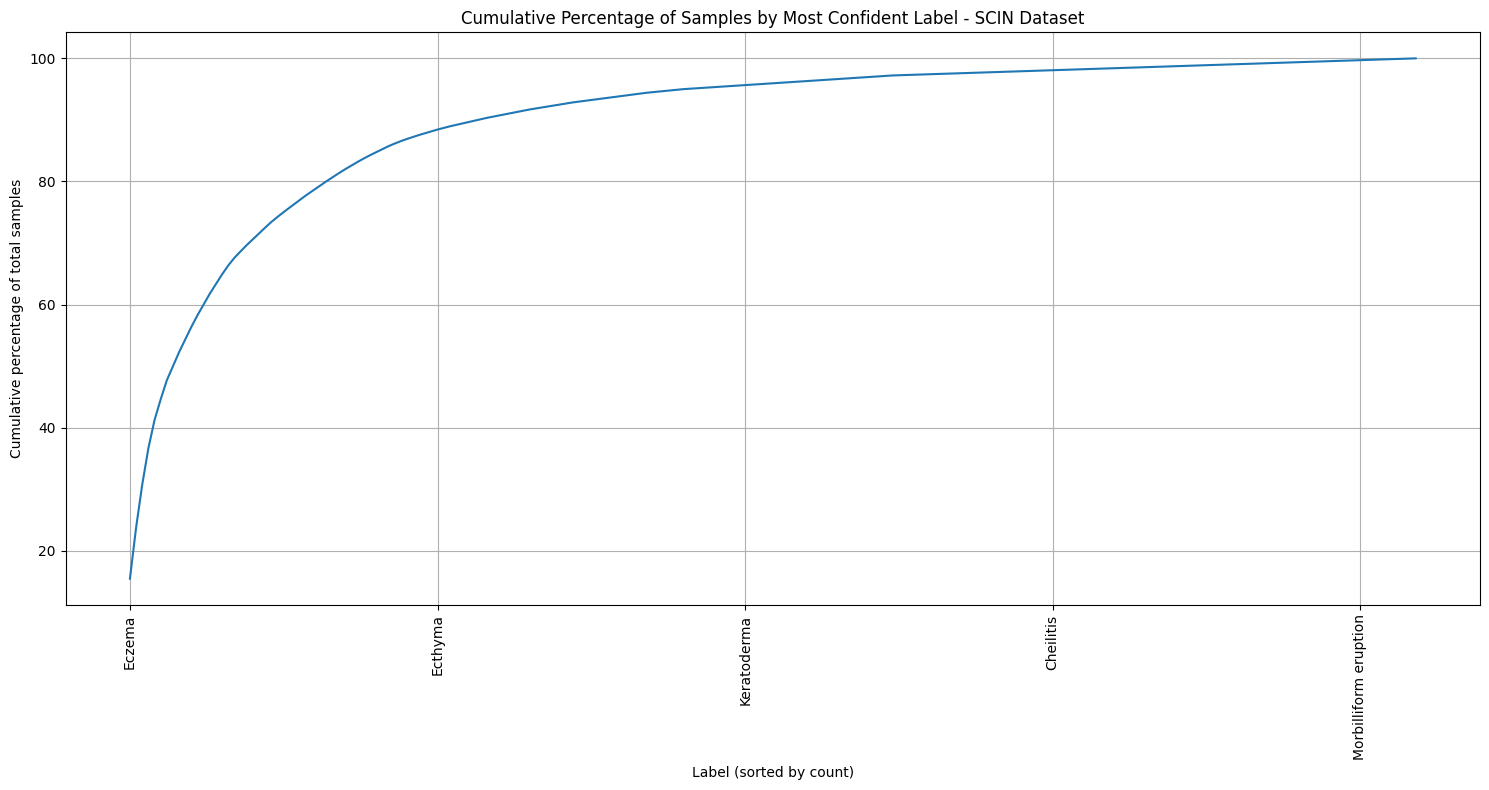

In [21]:
# --- Cumulative distribution analysis for SCIN ---
cumulative_counts_scin = scin_label_counts.sort_values(ascending=False).cumsum()
percentage_cumulative_scin = (cumulative_counts_scin / total_samples_scin) * 100

print("\n--- Cumulative percentage of samples by most confident label (top 15) ---")
print(percentage_cumulative_scin.head(15).to_string())

# Plot cumulative distribution
plt.figure(figsize=(15, 8))
percentage_cumulative_scin.plot()
plt.title('Cumulative Percentage of Samples by Most Confident Label - SCIN Dataset')
plt.xlabel('Label (sorted by count)')
plt.ylabel('Cumulative percentage of total samples')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.savefig('cumulative_scin_most_confident_label_distribution.png', dpi=300, bbox_inches='tight')
print("\nCumulative plot saved as cumulative_scin_most_confident_label_distribution.png")


In [22]:
# Additional analysis: Show some examples of the confidence extraction
print("\n--- Examples of confidence extraction ---")
sample_rows = scin_df_with_labels[['dermatologist_skin_condition_on_label_name', 
                                   'dermatologist_skin_condition_confidence', 
                                   'most_confident_label']].head(10)

for idx, row in sample_rows.iterrows():
    print(f"\nRow {idx}:")
    print(f"  Labels: {row['dermatologist_skin_condition_on_label_name']}")
    print(f"  Confidences: {row['dermatologist_skin_condition_confidence']}")
    print(f"  Most confident: {row['most_confident_label']}")



--- Examples of confidence extraction ---

Row 0:
  Labels: ['Inflicted skin lesions', 'Eczema', 'Irritant Contact Dermatitis']
  Confidences: [4, 4, 3]
  Most confident: Inflicted skin lesions

Row 1:
  Labels: ['Prurigo nodularis', 'Actinic Keratosis', 'SCC/SCCIS']
  Confidences: [4, 3, 4]
  Most confident: Prurigo nodularis

Row 2:
  Labels: ['Impetigo', 'Herpes Zoster', 'Bullous dermatitis']
  Confidences: [2, 1, 1]
  Most confident: Impetigo

Row 4:
  Labels: ['Lichen planus/lichenoid eruption', 'Folliculitis', 'Dermatosis due to flea']
  Confidences: [1, 1, 1]
  Most confident: Lichen planus/lichenoid eruption

Row 5:
  Labels: ['Drug Rash', 'Viral Exanthem', 'Eczema']
  Confidences: [2, 2, 1]
  Most confident: Drug Rash

Row 6:
  Labels: ['Urticaria', 'Leukocytoclastic Vasculitis', 'Urticaria', 'Insect Bite', 'Leukocytoclastic Vasculitis']
  Confidences: [4, 2, 5, 1, 1]
  Most confident: Urticaria

Row 7:
  Labels: ['Inflicted skin lesions', 'Basal Cell Carcinoma', 'SCC/SCCIS']

In [23]:
# Summary statistics
print("\n--- Dataset Summary ---")
print(f"Total cases in dataset: {len(scin_df)}")
print(f"Cases with valid dermatologist labels: {len(scin_df_with_labels)}")
print(f"Unique most confident labels: {scin_df_with_labels['most_confident_label'].nunique()}")

# Calculate average confidence score
def get_avg_confidence(row):
    try:
        confidences = ast.literal_eval(row['dermatologist_skin_condition_confidence'])
        return np.mean(confidences) if confidences else None
    except:
        return None

avg_confidences = scin_df_with_labels['dermatologist_skin_condition_confidence'].apply(get_avg_confidence)
print(f"Average confidence score: {avg_confidences.mean():.2f}")

# Show top 10 most common labels
print("\n--- Top 10 Most Common Most Confident Labels ---")
top_10_labels = scin_label_counts.head(10)
for label, count in top_10_labels.items():
    percentage = (count / total_samples_scin) * 100
    print(f"{label}: {count} samples ({percentage:.1f}%)")



--- Dataset Summary ---
Total cases in dataset: 5033
Cases with valid dermatologist labels: 3061
Unique most confident labels: 210
Average confidence score: nan

--- Top 10 Most Common Most Confident Labels ---
Eczema: 474 samples (15.5%)
Allergic Contact Dermatitis: 254 samples (8.3%)
Urticaria: 214 samples (7.0%)
Insect Bite: 181 samples (5.9%)
Folliculitis: 140 samples (4.6%)
Psoriasis: 103 samples (3.4%)
Tinea: 95 samples (3.1%)
Herpes Zoster: 70 samples (2.3%)
Impetigo: 70 samples (2.3%)
Acne: 63 samples (2.1%)


In [24]:
# Analysis of diseases with insufficient examples for LLM training
print("\n" + "="*80)
print("ANALYSIS OF DISEASES WITH INSUFFICIENT EXAMPLES FOR LLM TRAINING")
print("="*80)

# Define thresholds for insufficient examples
thresholds = [1, 2, 3, 5, 10, 20]

for threshold in thresholds:
    insufficient_labels = scin_label_counts[scin_label_counts <= threshold]
    total_insufficient_samples = insufficient_labels.sum()
    percentage_insufficient = (total_insufficient_samples / total_samples_scin) * 100
    
    print(f"\n--- Diseases with ≤ {threshold} example(s) ---")
    print(f"Number of diseases: {len(insufficient_labels)}")
    print(f"Total samples: {total_insufficient_samples}")
    print(f"Percentage of dataset: {percentage_insufficient:.1f}%")
    
    if len(insufficient_labels) > 0:
        print(f"Diseases: {list(insufficient_labels.index)}")

print(f"\n--- Summary of Training Challenges ---")
print(f"Total unique diseases: {len(scin_label_counts)}")
print(f"Diseases with only 1 example: {len(scin_label_counts[scin_label_counts == 1])}")
print(f"Diseases with ≤ 5 examples: {len(scin_label_counts[scin_label_counts <= 5])}")
print(f"Diseases with ≤ 10 examples: {len(scin_label_counts[scin_label_counts <= 10])}")
print(f"Diseases with ≤ 20 examples: {len(scin_label_counts[scin_label_counts <= 20])}")

# Calculate what percentage of diseases would be problematic
print(f"\n--- LLM Training Impact Analysis ---")
for threshold in [5, 10, 20]:
    problematic_diseases = len(scin_label_counts[scin_label_counts <= threshold])
    percentage_problematic = (problematic_diseases / len(scin_label_counts)) * 100
    print(f"Diseases with ≤ {threshold} examples: {problematic_diseases} ({percentage_problematic:.1f}% of all diseases)")



ANALYSIS OF DISEASES WITH INSUFFICIENT EXAMPLES FOR LLM TRAINING

--- Diseases with ≤ 1 example(s) ---
Number of diseases: 85
Total samples: 85
Percentage of dataset: 2.8%
Diseases: ['Chicken pox exanthem', 'Lentigo', 'Contact dermatitis caused by Rhus diversiloba', 'Melanin pigmentation due to exogenous substance', 'Traction alopecia', 'Infection of skin', 'Skin lesion in drug addict', 'unilateral laterothoracic exanthem', 'Localised cutaneous vasculitis', 'Acral persistent papular mucinosis', 'Onychodystrophy', 'Sweet syndrome', 'Hyperpigmentation', 'Arsenical keratosis', 'Melanoma', 'varicose vein', 'Nodular vasculitis', 'Erythema dyschromicum perstans', 'Morbilliform eruption', 'Adnexal neoplasm', 'Photocontact dermatitis [berloque dermatitis]', 'Lymphangioma', 'Foreign body reaction of the skin', 'relapsing polychondritis', 'Lichenified eczema', 'Skin ulcer', 'Mycetoma', 'Acute-on-chronic dyshidrotic eczema of hands', 'Acute vesicular dermatitis', 'Condyloma acuminatum', 'Foot ul

In [25]:
# Detailed analysis of single-example diseases (completely useless for training)
print("\n" + "="*80)
print("DISEASES WITH ONLY 1 EXAMPLE - COMPLETELY USELESS FOR LLM TRAINING")
print("="*80)

single_example_diseases = scin_label_counts[scin_label_counts == 1]
print(f"Number of diseases with only 1 example: {len(single_example_diseases)}")
print(f"These represent {len(single_example_diseases)} samples out of {total_samples_scin} total samples")

if len(single_example_diseases) > 0:
    print(f"\nDiseases with only 1 example:")
    for i, (disease, count) in enumerate(single_example_diseases.items(), 1):
        print(f"{i:2d}. {disease}")
    
    print(f"\n--- Recommendation for LLM Training ---")
    print(f"❌ REMOVE these {len(single_example_diseases)} diseases from training data")
    print(f"❌ They provide no learning signal and will confuse the model")
    print(f"❌ Better to have fewer, well-represented diseases than many single-example diseases")

# Analysis of diseases with 2-5 examples (very problematic)
print(f"\n" + "="*80)
print("DISEASES WITH 2-5 EXAMPLES - VERY PROBLEMATIC FOR LLM TRAINING")
print("="*80)

few_example_diseases = scin_label_counts[(scin_label_counts >= 2) & (scin_label_counts <= 5)]
print(f"Number of diseases with 2-5 examples: {len(few_example_diseases)}")
print(f"Total samples in this category: {few_example_diseases.sum()}")

if len(few_example_diseases) > 0:
    print(f"\nDiseases with 2-5 examples:")
    for i, (disease, count) in enumerate(few_example_diseases.items(), 1):
        print(f"{i:2d}. {disease} ({count} examples)")
    
    print(f"\n--- Recommendation for LLM Training ---")
    print(f"⚠️  CONSIDER REMOVING these {len(few_example_diseases)} diseases")
    print(f"⚠️  Very few examples make it hard for LLM to learn patterns")
    print(f"⚠️  May cause overfitting or poor generalization")

# Analysis of diseases with 6-20 examples (problematic but potentially usable)
print(f"\n" + "="*80)
print("DISEASES WITH 6-20 EXAMPLES - PROBLEMATIC BUT POTENTIALLY USABLE")
print("="*80)

moderate_example_diseases = scin_label_counts[(scin_label_counts >= 6) & (scin_label_counts <= 20)]
print(f"Number of diseases with 6-20 examples: {len(moderate_example_diseases)}")
print(f"Total samples in this category: {moderate_example_diseases.sum()}")

if len(moderate_example_diseases) > 0:
    print(f"\nTop 10 diseases with 6-20 examples:")
    top_moderate = moderate_example_diseases.head(10)
    for i, (disease, count) in enumerate(top_moderate.items(), 1):
        print(f"{i:2d}. {disease} ({count} examples)")
    
    print(f"\n--- Recommendation for LLM Training ---")
    print(f"⚠️  USE WITH CAUTION - consider data augmentation")
    print(f"⚠️  Monitor performance closely for these diseases")
    print(f"⚠️  May benefit from few-shot learning techniques")



DISEASES WITH ONLY 1 EXAMPLE - COMPLETELY USELESS FOR LLM TRAINING
Number of diseases with only 1 example: 85
These represent 85 samples out of 3061 total samples

Diseases with only 1 example:
 1. Chicken pox exanthem
 2. Lentigo
 3. Contact dermatitis caused by Rhus diversiloba
 4. Melanin pigmentation due to exogenous substance
 5. Traction alopecia
 6. Infection of skin
 7. Skin lesion in drug addict
 8. unilateral laterothoracic exanthem
 9. Localised cutaneous vasculitis
10. Acral persistent papular mucinosis
11. Onychodystrophy
12. Sweet syndrome
13. Hyperpigmentation
14. Arsenical keratosis
15. Melanoma
16. varicose vein
17. Nodular vasculitis
18. Erythema dyschromicum perstans
19. Morbilliform eruption
20. Adnexal neoplasm
21. Photocontact dermatitis [berloque dermatitis]
22. Lymphangioma
23. Foreign body reaction of the skin
24. relapsing polychondritis
25. Lichenified eczema
26. Skin ulcer
27. Mycetoma
28. Acute-on-chronic dyshidrotic eczema of hands
29. Acute vesicular der


Training suitability chart saved as scin_training_suitability_analysis.png

TRAINING DECISION SUMMARY
Total diseases in dataset: 210

❌ Remove completely (≤1 example): 85 diseases (40.5%)
⚠️  Consider removing (2-5 examples): 59 diseases (28.1%)
⚠️  Use with caution (6-20 examples): 33 diseases (15.7%)
✅ Adequate for training (21-50 examples): 19 diseases (9.0%)
✅ Good for training (50+ examples): 14 diseases (6.7%)

--- Recommended Action ---
🚨 HIGH PRIORITY: 144 diseases (68.6%) should be removed/considered for removal
   This represents a significant portion of your dataset that may hurt model performance


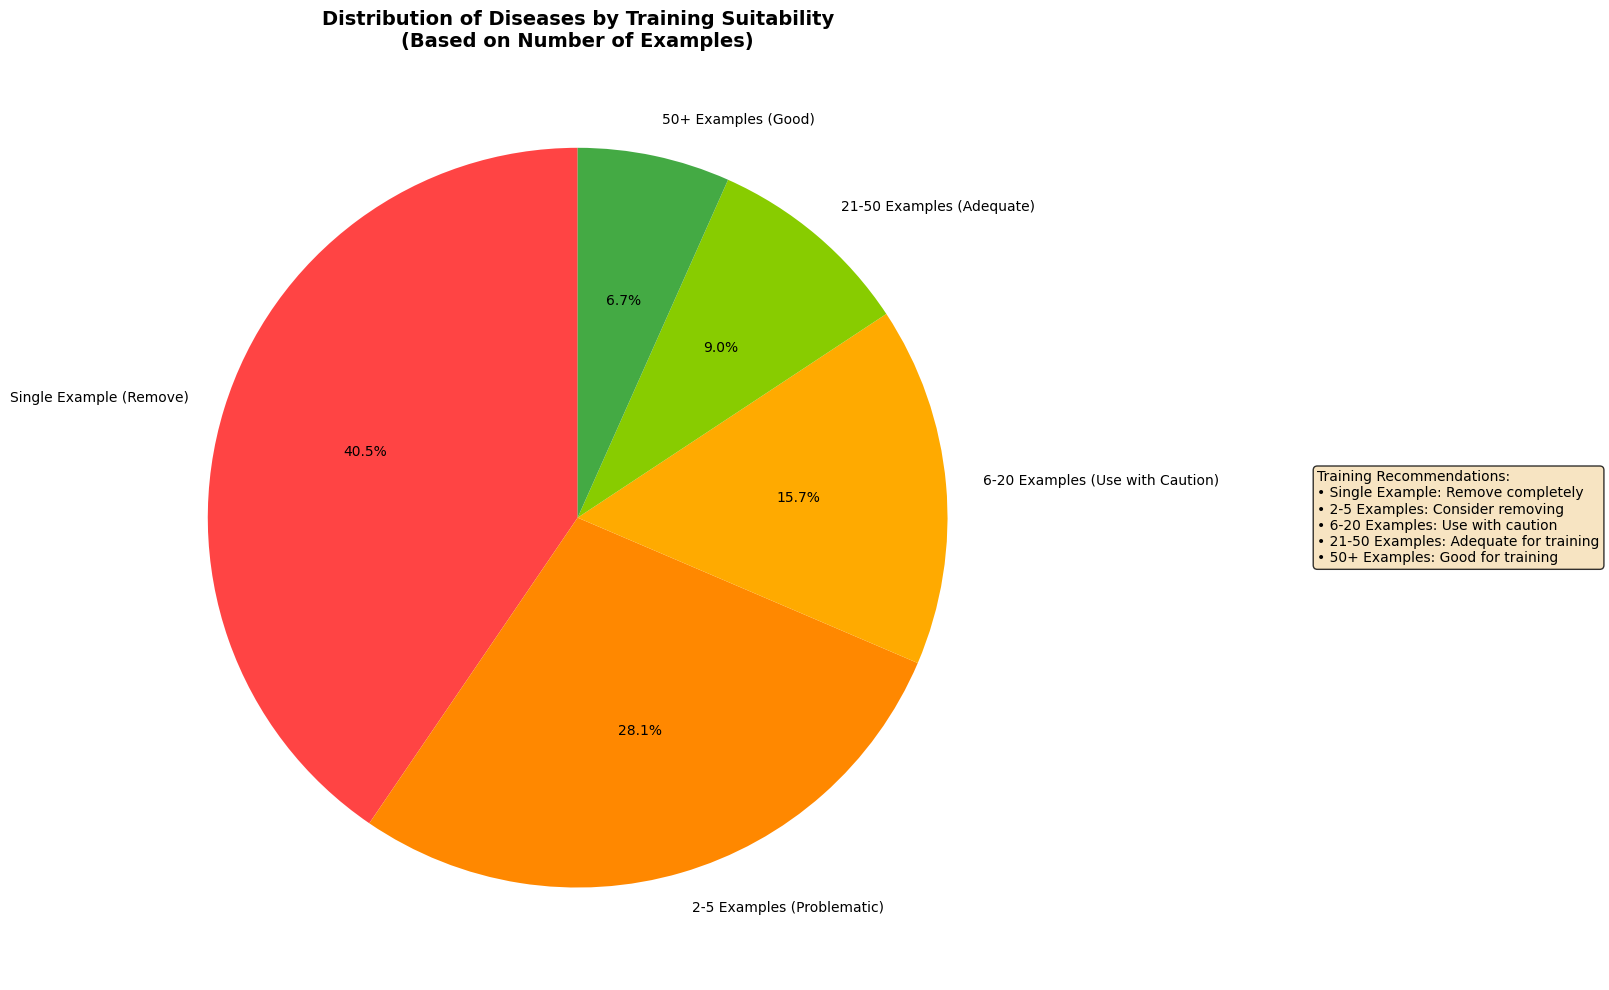

In [26]:
# Visualization of training suitability
plt.figure(figsize=(15, 10))

# Create categories for visualization
categories = {
    'Single Example (Remove)': len(scin_label_counts[scin_label_counts == 1]),
    '2-5 Examples (Problematic)': len(scin_label_counts[(scin_label_counts >= 2) & (scin_label_counts <= 5)]),
    '6-20 Examples (Use with Caution)': len(scin_label_counts[(scin_label_counts >= 6) & (scin_label_counts <= 20)]),
    '21-50 Examples (Adequate)': len(scin_label_counts[(scin_label_counts >= 21) & (scin_label_counts <= 50)]),
    '50+ Examples (Good)': len(scin_label_counts[scin_label_counts > 50])
}

# Create pie chart
colors = ['#ff4444', '#ff8800', '#ffaa00', '#88cc00', '#44aa44']
plt.pie(categories.values(), labels=categories.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribution of Diseases by Training Suitability\n(Based on Number of Examples)', fontsize=14, fontweight='bold')

# Add text box with recommendations
textstr = '''Training Recommendations:
• Single Example: Remove completely
• 2-5 Examples: Consider removing
• 6-20 Examples: Use with caution
• 21-50 Examples: Adequate for training
• 50+ Examples: Good for training'''
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(1.3, 0.5, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', bbox=props)

plt.tight_layout()
plt.savefig('scin_training_suitability_analysis.png', dpi=300, bbox_inches='tight')
print("\nTraining suitability chart saved as scin_training_suitability_analysis.png")

# Summary statistics for training decisions
print(f"\n" + "="*80)
print("TRAINING DECISION SUMMARY")
print("="*80)

total_diseases = len(scin_label_counts)
remove_completely = len(scin_label_counts[scin_label_counts <= 1])
consider_removing = len(scin_label_counts[(scin_label_counts >= 2) & (scin_label_counts <= 5)])
use_with_caution = len(scin_label_counts[(scin_label_counts >= 6) & (scin_label_counts <= 20)])
adequate_for_training = len(scin_label_counts[(scin_label_counts >= 21) & (scin_label_counts <= 50)])
good_for_training = len(scin_label_counts[scin_label_counts > 50])

print(f"Total diseases in dataset: {total_diseases}")
print(f"")
print(f"❌ Remove completely (≤1 example): {remove_completely} diseases ({remove_completely/total_diseases*100:.1f}%)")
print(f"⚠️  Consider removing (2-5 examples): {consider_removing} diseases ({consider_removing/total_diseases*100:.1f}%)")
print(f"⚠️  Use with caution (6-20 examples): {use_with_caution} diseases ({use_with_caution/total_diseases*100:.1f}%)")
print(f"✅ Adequate for training (21-50 examples): {adequate_for_training} diseases ({adequate_for_training/total_diseases*100:.1f}%)")
print(f"✅ Good for training (50+ examples): {good_for_training} diseases ({good_for_training/total_diseases*100:.1f}%)")

print(f"\n--- Recommended Action ---")
if remove_completely + consider_removing > total_diseases * 0.3:
    print(f"🚨 HIGH PRIORITY: {remove_completely + consider_removing} diseases ({((remove_completely + consider_removing)/total_diseases*100):.1f}%) should be removed/considered for removal")
    print(f"   This represents a significant portion of your dataset that may hurt model performance")
else:
    print(f"✅ MANAGEABLE: Only {remove_completely + consider_removing} diseases ({((remove_completely + consider_removing)/total_diseases*100):.1f}%) are problematic")
    print(f"   Most diseases have sufficient examples for training")


In [27]:
dataset_path = 'data/ddidiversedermatologyimages/ddi_metadata.csv'
ddi_df = pd.read_csv(dataset_path)

# Analysis of diseases with insufficient examples for LLM training - DDI Dataset
print("\n" + "="*80)
print("ANALYSIS OF DISEASES WITH INSUFFICIENT EXAMPLES FOR LLM TRAINING - DDI DATASET")
print("="*80)

# Count the occurrences of each disease in DDI
ddi_disease_counts = ddi_df['disease'].value_counts()

# Define thresholds for insufficient examples
thresholds = [1, 2, 3, 5, 10, 20]

for threshold in thresholds:
    insufficient_diseases = ddi_disease_counts[ddi_disease_counts <= threshold]
    total_insufficient_samples = insufficient_diseases.sum()
    percentage_insufficient = (total_insufficient_samples / len(ddi_df)) * 100
    
    print(f"\n--- Diseases with ≤ {threshold} example(s) ---")
    print(f"Number of diseases: {len(insufficient_diseases)}")
    print(f"Total samples: {total_insufficient_samples}")
    print(f"Percentage of dataset: {percentage_insufficient:.1f}%")
    
    if len(insufficient_diseases) > 0:
        print(f"Diseases: {list(insufficient_diseases.index)}")

print(f"\n--- Summary of Training Challenges - DDI ---")
print(f"Total unique diseases: {len(ddi_disease_counts)}")
print(f"Diseases with only 1 example: {len(ddi_disease_counts[ddi_disease_counts == 1])}")
print(f"Diseases with ≤ 5 examples: {len(ddi_disease_counts[ddi_disease_counts <= 5])}")
print(f"Diseases with ≤ 10 examples: {len(ddi_disease_counts[ddi_disease_counts <= 10])}")
print(f"Diseases with ≤ 20 examples: {len(ddi_disease_counts[ddi_disease_counts <= 20])}")

# Calculate what percentage of diseases would be problematic
print(f"\n--- LLM Training Impact Analysis - DDI ---")
for threshold in [5, 10, 20]:
    problematic_diseases = len(ddi_disease_counts[ddi_disease_counts <= threshold])
    percentage_problematic = (problematic_diseases / len(ddi_disease_counts)) * 100
    print(f"Diseases with ≤ {threshold} examples: {problematic_diseases} ({percentage_problematic:.1f}% of all diseases)")



ANALYSIS OF DISEASES WITH INSUFFICIENT EXAMPLES FOR LLM TRAINING - DDI DATASET

--- Diseases with ≤ 1 example(s) ---
Number of diseases: 30
Total samples: 30
Percentage of dataset: 4.6%
Diseases: ['subcutaneous-t-cell-lymphoma', 'lichenoid-keratosis', 'reactive-lymphoid-hyperplasia', 'coccidioidomycosis', 'leukemia-cutis', 'sebaceous-carcinoma', 'chondroid-syringoma', 'tinea-pedis', 'hematoma', 'folliculitis', 'atypical-spindle-cell-nevus-of-reed', 'lymphocytic-infiltrations', 'angioleiomyoma', 'keloid', 'acne-cystic', 'verruciform-xanthoma', 'morphea', 'neuroma', 'wart', 'epidermal-nevus', 'focal-acral-hyperkeratosis', 'nodular-melanoma-(nm)', 'pigmented-spindle-cell-nevus-of-reed', 'dermatomyositis', 'glomangioma', 'cellular-neurothekeoma', 'clear-cell-acanthoma', 'abscess', 'blastic-plasmacytoid-dendritic-cell-neoplasm', 'acral-melanotic-macule']

--- Diseases with ≤ 2 example(s) ---
Number of diseases: 41
Total samples: 52
Percentage of dataset: 7.9%
Diseases: ['foreign-body-granu

In [28]:
# Detailed analysis of single-example diseases (completely useless for training) - DDI
print("\n" + "="*80)
print("DISEASES WITH ONLY 1 EXAMPLE - COMPLETELY USELESS FOR LLM TRAINING - DDI")
print("="*80)

single_example_diseases_ddi = ddi_disease_counts[ddi_disease_counts == 1]
print(f"Number of diseases with only 1 example: {len(single_example_diseases_ddi)}")
print(f"These represent {len(single_example_diseases_ddi)} samples out of {len(ddi_df)} total samples")

if len(single_example_diseases_ddi) > 0:
    print(f"\nDiseases with only 1 example:")
    for i, (disease, count) in enumerate(single_example_diseases_ddi.items(), 1):
        print(f"{i:2d}. {disease}")
    
    print(f"\n--- Recommendation for LLM Training - DDI ---")
    print(f"❌ REMOVE these {len(single_example_diseases_ddi)} diseases from training data")
    print(f"❌ They provide no learning signal and will confuse the model")
    print(f"❌ Better to have fewer, well-represented diseases than many single-example diseases")

# Analysis of diseases with 2-5 examples (very problematic) - DDI
print(f"\n" + "="*80)
print("DISEASES WITH 2-5 EXAMPLES - VERY PROBLEMATIC FOR LLM TRAINING - DDI")
print("="*80)

few_example_diseases_ddi = ddi_disease_counts[(ddi_disease_counts >= 2) & (ddi_disease_counts <= 5)]
print(f"Number of diseases with 2-5 examples: {len(few_example_diseases_ddi)}")
print(f"Total samples in this category: {few_example_diseases_ddi.sum()}")

if len(few_example_diseases_ddi) > 0:
    print(f"\nDiseases with 2-5 examples:")
    for i, (disease, count) in enumerate(few_example_diseases_ddi.items(), 1):
        print(f"{i:2d}. {disease} ({count} examples)")
    
    print(f"\n--- Recommendation for LLM Training - DDI ---")
    print(f"⚠️  CONSIDER REMOVING these {len(few_example_diseases_ddi)} diseases")
    print(f"⚠️  Very few examples make it hard for LLM to learn patterns")
    print(f"⚠️  May cause overfitting or poor generalization")

# Analysis of diseases with 6-20 examples (problematic but potentially usable) - DDI
print(f"\n" + "="*80)
print("DISEASES WITH 6-20 EXAMPLES - PROBLEMATIC BUT POTENTIALLY USABLE - DDI")
print("="*80)

moderate_example_diseases_ddi = ddi_disease_counts[(ddi_disease_counts >= 6) & (ddi_disease_counts <= 20)]
print(f"Number of diseases with 6-20 examples: {len(moderate_example_diseases_ddi)}")
print(f"Total samples in this category: {moderate_example_diseases_ddi.sum()}")

if len(moderate_example_diseases_ddi) > 0:
    print(f"\nTop 10 diseases with 6-20 examples:")
    top_moderate_ddi = moderate_example_diseases_ddi.head(10)
    for i, (disease, count) in enumerate(top_moderate_ddi.items(), 1):
        print(f"{i:2d}. {disease} ({count} examples)")
    
    print(f"\n--- Recommendation for LLM Training - DDI ---")
    print(f"⚠️  USE WITH CAUTION - consider data augmentation")
    print(f"⚠️  Monitor performance closely for these diseases")
    print(f"⚠️  May benefit from few-shot learning techniques")



DISEASES WITH ONLY 1 EXAMPLE - COMPLETELY USELESS FOR LLM TRAINING - DDI
Number of diseases with only 1 example: 30
These represent 30 samples out of 656 total samples

Diseases with only 1 example:
 1. subcutaneous-t-cell-lymphoma
 2. lichenoid-keratosis
 3. reactive-lymphoid-hyperplasia
 4. coccidioidomycosis
 5. leukemia-cutis
 6. sebaceous-carcinoma
 7. chondroid-syringoma
 8. tinea-pedis
 9. hematoma
10. folliculitis
11. atypical-spindle-cell-nevus-of-reed
12. lymphocytic-infiltrations
13. angioleiomyoma
14. keloid
15. acne-cystic
16. verruciform-xanthoma
17. morphea
18. neuroma
19. wart
20. epidermal-nevus
21. focal-acral-hyperkeratosis
22. nodular-melanoma-(nm)
23. pigmented-spindle-cell-nevus-of-reed
24. dermatomyositis
25. glomangioma
26. cellular-neurothekeoma
27. clear-cell-acanthoma
28. abscess
29. blastic-plasmacytoid-dendritic-cell-neoplasm
30. acral-melanotic-macule

--- Recommendation for LLM Training - DDI ---
❌ REMOVE these 30 diseases from training data
❌ They provi

In [29]:
dataset_path = 'data/fitzpatrick17k/fitzpatrick17k.csv'
fitz_df = pd.read_csv(dataset_path)

# Analysis of diseases with insufficient examples for LLM training - Fitzpatrick17k Dataset
print("\n" + "="*80)
print("ANALYSIS OF DISEASES WITH INSUFFICIENT EXAMPLES FOR LLM TRAINING - FITZPATRICK17K")
print("="*80)

# Count the occurrences of each label in Fitzpatrick17k
fitz_label_counts = fitz_df['label'].value_counts()

# Define thresholds for insufficient examples
thresholds = [1, 2, 3, 5, 10, 20]

for threshold in thresholds:
    insufficient_labels = fitz_label_counts[fitz_label_counts <= threshold]
    total_insufficient_samples = insufficient_labels.sum()
    percentage_insufficient = (total_insufficient_samples / len(fitz_df)) * 100
    
    print(f"\n--- Labels with ≤ {threshold} example(s) ---")
    print(f"Number of labels: {len(insufficient_labels)}")
    print(f"Total samples: {total_insufficient_samples}")
    print(f"Percentage of dataset: {percentage_insufficient:.1f}%")
    
    if len(insufficient_labels) > 0 and len(insufficient_labels) <= 20:  # Only show if not too many
        print(f"Labels: {list(insufficient_labels.index)}")
    elif len(insufficient_labels) > 20:
        print(f"Too many labels to list ({len(insufficient_labels)} total)")

print(f"\n--- Summary of Training Challenges - Fitzpatrick17k ---")
print(f"Total unique labels: {len(fitz_label_counts)}")
print(f"Labels with only 1 example: {len(fitz_label_counts[fitz_label_counts == 1])}")
print(f"Labels with ≤ 5 examples: {len(fitz_label_counts[fitz_label_counts <= 5])}")
print(f"Labels with ≤ 10 examples: {len(fitz_label_counts[fitz_label_counts <= 10])}")
print(f"Labels with ≤ 20 examples: {len(fitz_label_counts[fitz_label_counts <= 20])}")

# Calculate what percentage of labels would be problematic
print(f"\n--- LLM Training Impact Analysis - Fitzpatrick17k ---")
for threshold in [5, 10, 20]:
    problematic_labels = len(fitz_label_counts[fitz_label_counts <= threshold])
    percentage_problematic = (problematic_labels / len(fitz_label_counts)) * 100
    print(f"Labels with ≤ {threshold} examples: {problematic_labels} ({percentage_problematic:.1f}% of all labels)")



ANALYSIS OF DISEASES WITH INSUFFICIENT EXAMPLES FOR LLM TRAINING - FITZPATRICK17K

--- Labels with ≤ 1 example(s) ---
Number of labels: 0
Total samples: 0
Percentage of dataset: 0.0%

--- Labels with ≤ 2 example(s) ---
Number of labels: 0
Total samples: 0
Percentage of dataset: 0.0%

--- Labels with ≤ 3 example(s) ---
Number of labels: 0
Total samples: 0
Percentage of dataset: 0.0%

--- Labels with ≤ 5 example(s) ---
Number of labels: 0
Total samples: 0
Percentage of dataset: 0.0%

--- Labels with ≤ 10 example(s) ---
Number of labels: 0
Total samples: 0
Percentage of dataset: 0.0%

--- Labels with ≤ 20 example(s) ---
Number of labels: 0
Total samples: 0
Percentage of dataset: 0.0%

--- Summary of Training Challenges - Fitzpatrick17k ---
Total unique labels: 114
Labels with only 1 example: 0
Labels with ≤ 5 examples: 0
Labels with ≤ 10 examples: 0
Labels with ≤ 20 examples: 0

--- LLM Training Impact Analysis - Fitzpatrick17k ---
Labels with ≤ 5 examples: 0 (0.0% of all labels)
Labels 

In [30]:
# Detailed analysis of single-example labels (completely useless for training) - Fitzpatrick17k
print("\n" + "="*80)
print("LABELS WITH ONLY 1 EXAMPLE - COMPLETELY USELESS FOR LLM TRAINING - FITZPATRICK17K")
print("="*80)

single_example_labels_fitz = fitz_label_counts[fitz_label_counts == 1]
print(f"Number of labels with only 1 example: {len(single_example_labels_fitz)}")
print(f"These represent {len(single_example_labels_fitz)} samples out of {len(fitz_df)} total samples")

if len(single_example_labels_fitz) > 0:
    print(f"\nFirst 20 labels with only 1 example:")
    for i, (label, count) in enumerate(single_example_labels_fitz.head(20).items(), 1):
        print(f"{i:2d}. {label}")
    
    if len(single_example_labels_fitz) > 20:
        print(f"... and {len(single_example_labels_fitz) - 20} more labels with only 1 example")
    
    print(f"\n--- Recommendation for LLM Training - Fitzpatrick17k ---")
    print(f"❌ REMOVE these {len(single_example_labels_fitz)} labels from training data")
    print(f"❌ They provide no learning signal and will confuse the model")
    print(f"❌ Better to have fewer, well-represented labels than many single-example labels")

# Analysis of labels with 2-5 examples (very problematic) - Fitzpatrick17k
print(f"\n" + "="*80)
print("LABELS WITH 2-5 EXAMPLES - VERY PROBLEMATIC FOR LLM TRAINING - FITZPATRICK17K")
print("="*80)

few_example_labels_fitz = fitz_label_counts[(fitz_label_counts >= 2) & (fitz_label_counts <= 5)]
print(f"Number of labels with 2-5 examples: {len(few_example_labels_fitz)}")
print(f"Total samples in this category: {few_example_labels_fitz.sum()}")

if len(few_example_labels_fitz) > 0:
    print(f"\nFirst 20 labels with 2-5 examples:")
    for i, (label, count) in enumerate(few_example_labels_fitz.head(20).items(), 1):
        print(f"{i:2d}. {label} ({count} examples)")
    
    if len(few_example_labels_fitz) > 20:
        print(f"... and {len(few_example_labels_fitz) - 20} more labels with 2-5 examples")
    
    print(f"\n--- Recommendation for LLM Training - Fitzpatrick17k ---")
    print(f"⚠️  CONSIDER REMOVING these {len(few_example_labels_fitz)} labels")
    print(f"⚠️  Very few examples make it hard for LLM to learn patterns")
    print(f"⚠️  May cause overfitting or poor generalization")

# Analysis of labels with 6-20 examples (problematic but potentially usable) - Fitzpatrick17k
print(f"\n" + "="*80)
print("LABELS WITH 6-20 EXAMPLES - PROBLEMATIC BUT POTENTIALLY USABLE - FITZPATRICK17K")
print("="*80)

moderate_example_labels_fitz = fitz_label_counts[(fitz_label_counts >= 6) & (fitz_label_counts <= 20)]
print(f"Number of labels with 6-20 examples: {len(moderate_example_labels_fitz)}")
print(f"Total samples in this category: {moderate_example_labels_fitz.sum()}")

if len(moderate_example_labels_fitz) > 0:
    print(f"\nTop 20 labels with 6-20 examples:")
    top_moderate_fitz = moderate_example_labels_fitz.head(20)
    for i, (label, count) in enumerate(top_moderate_fitz.items(), 1):
        print(f"{i:2d}. {label} ({count} examples)")
    
    if len(moderate_example_labels_fitz) > 20:
        print(f"... and {len(moderate_example_labels_fitz) - 20} more labels with 6-20 examples")
    
    print(f"\n--- Recommendation for LLM Training - Fitzpatrick17k ---")
    print(f"⚠️  USE WITH CAUTION - consider data augmentation")
    print(f"⚠️  Monitor performance closely for these labels")
    print(f"⚠️  May benefit from few-shot learning techniques")



LABELS WITH ONLY 1 EXAMPLE - COMPLETELY USELESS FOR LLM TRAINING - FITZPATRICK17K
Number of labels with only 1 example: 0
These represent 0 samples out of 16577 total samples

LABELS WITH 2-5 EXAMPLES - VERY PROBLEMATIC FOR LLM TRAINING - FITZPATRICK17K
Number of labels with 2-5 examples: 0
Total samples in this category: 0

LABELS WITH 6-20 EXAMPLES - PROBLEMATIC BUT POTENTIALLY USABLE - FITZPATRICK17K
Number of labels with 6-20 examples: 0
Total samples in this category: 0



Training suitability comparison chart saved as all_datasets_training_suitability_comparison.png


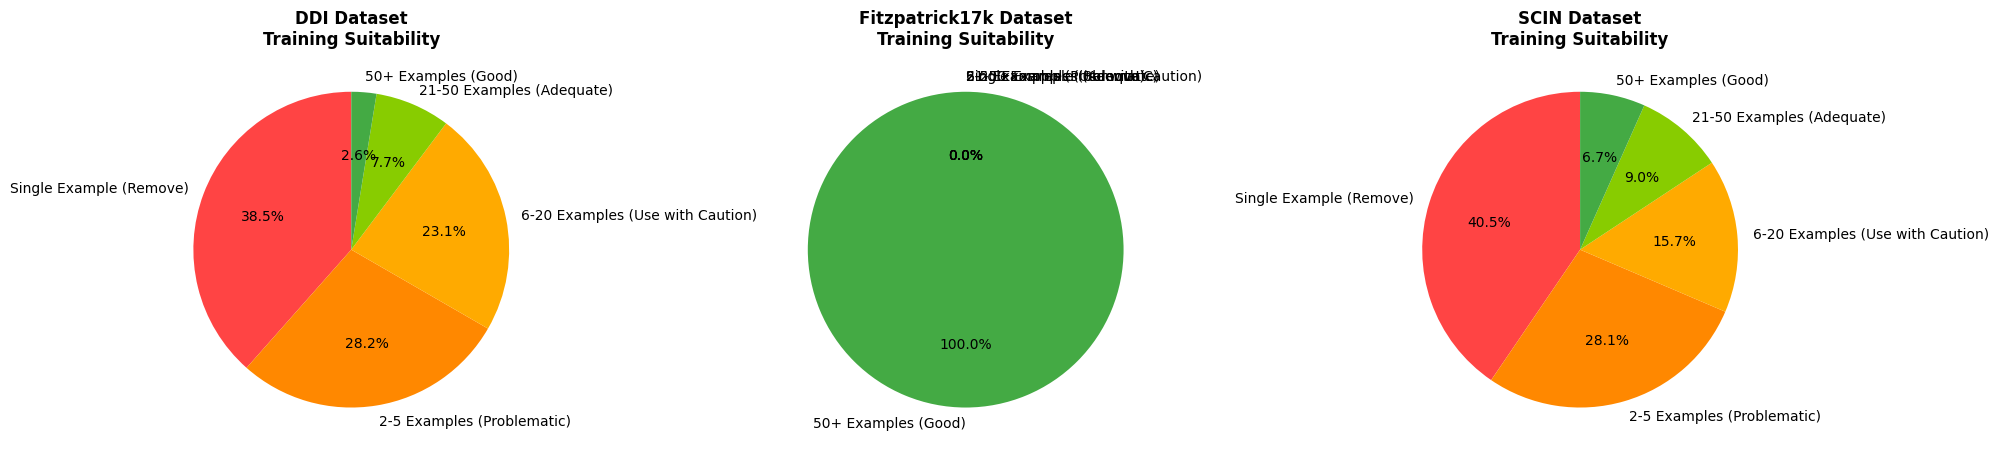

In [31]:
# Visualization of training suitability for all three datasets
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# DDI Dataset
categories_ddi = {
    'Single Example (Remove)': len(ddi_disease_counts[ddi_disease_counts == 1]),
    '2-5 Examples (Problematic)': len(ddi_disease_counts[(ddi_disease_counts >= 2) & (ddi_disease_counts <= 5)]),
    '6-20 Examples (Use with Caution)': len(ddi_disease_counts[(ddi_disease_counts >= 6) & (ddi_disease_counts <= 20)]),
    '21-50 Examples (Adequate)': len(ddi_disease_counts[(ddi_disease_counts >= 21) & (ddi_disease_counts <= 50)]),
    '50+ Examples (Good)': len(ddi_disease_counts[ddi_disease_counts > 50])
}

colors = ['#ff4444', '#ff8800', '#ffaa00', '#88cc00', '#44aa44']
axes[0].pie(categories_ddi.values(), labels=categories_ddi.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('DDI Dataset\nTraining Suitability', fontsize=12, fontweight='bold')

# Fitzpatrick17k Dataset
categories_fitz = {
    'Single Example (Remove)': len(fitz_label_counts[fitz_label_counts == 1]),
    '2-5 Examples (Problematic)': len(fitz_label_counts[(fitz_label_counts >= 2) & (fitz_label_counts <= 5)]),
    '6-20 Examples (Use with Caution)': len(fitz_label_counts[(fitz_label_counts >= 6) & (fitz_label_counts <= 20)]),
    '21-50 Examples (Adequate)': len(fitz_label_counts[(fitz_label_counts >= 21) & (fitz_label_counts <= 50)]),
    '50+ Examples (Good)': len(fitz_label_counts[fitz_label_counts > 50])
}

axes[1].pie(categories_fitz.values(), labels=categories_fitz.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Fitzpatrick17k Dataset\nTraining Suitability', fontsize=12, fontweight='bold')

# SCIN Dataset
categories_scin = {
    'Single Example (Remove)': len(scin_label_counts[scin_label_counts == 1]),
    '2-5 Examples (Problematic)': len(scin_label_counts[(scin_label_counts >= 2) & (scin_label_counts <= 5)]),
    '6-20 Examples (Use with Caution)': len(scin_label_counts[(scin_label_counts >= 6) & (scin_label_counts <= 20)]),
    '21-50 Examples (Adequate)': len(scin_label_counts[(scin_label_counts >= 21) & (scin_label_counts <= 50)]),
    '50+ Examples (Good)': len(scin_label_counts[scin_label_counts > 50])
}

axes[2].pie(categories_scin.values(), labels=categories_scin.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
axes[2].set_title('SCIN Dataset\nTraining Suitability', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('all_datasets_training_suitability_comparison.png', dpi=300, bbox_inches='tight')
print("\nTraining suitability comparison chart saved as all_datasets_training_suitability_comparison.png")


In [32]:
# Summary comparison of all three datasets
print("\n" + "="*100)
print("COMPREHENSIVE TRAINING DECISION SUMMARY - ALL DATASETS")
print("="*100)

datasets = {
    'DDI': {
        'total_categories': len(ddi_disease_counts),
        'total_samples': len(ddi_df),
        'single_example': len(ddi_disease_counts[ddi_disease_counts == 1]),
        'few_examples': len(ddi_disease_counts[(ddi_disease_counts >= 2) & (ddi_disease_counts <= 5)]),
        'moderate_examples': len(ddi_disease_counts[(ddi_disease_counts >= 6) & (ddi_disease_counts <= 20)]),
        'adequate_examples': len(ddi_disease_counts[(ddi_disease_counts >= 21) & (ddi_disease_counts <= 50)]),
        'good_examples': len(ddi_disease_counts[ddi_disease_counts > 50])
    },
    'Fitzpatrick17k': {
        'total_categories': len(fitz_label_counts),
        'total_samples': len(fitz_df),
        'single_example': len(fitz_label_counts[fitz_label_counts == 1]),
        'few_examples': len(fitz_label_counts[(fitz_label_counts >= 2) & (fitz_label_counts <= 5)]),
        'moderate_examples': len(fitz_label_counts[(fitz_label_counts >= 6) & (fitz_label_counts <= 20)]),
        'adequate_examples': len(fitz_label_counts[(fitz_label_counts >= 21) & (fitz_label_counts <= 50)]),
        'good_examples': len(fitz_label_counts[fitz_label_counts > 50])
    },
    'SCIN': {
        'total_categories': len(scin_label_counts),
        'total_samples': len(scin_df_with_labels),
        'single_example': len(scin_label_counts[scin_label_counts == 1]),
        'few_examples': len(scin_label_counts[(scin_label_counts >= 2) & (scin_label_counts <= 5)]),
        'moderate_examples': len(scin_label_counts[(scin_label_counts >= 6) & (scin_label_counts <= 20)]),
        'adequate_examples': len(scin_label_counts[(scin_label_counts >= 21) & (scin_label_counts <= 50)]),
        'good_examples': len(scin_label_counts[scin_label_counts > 50])
    }
}

print(f"{'Dataset':<15} {'Total Categories':<15} {'Total Samples':<15} {'Single (Remove)':<15} {'Few (Problematic)':<18} {'Moderate (Caution)':<18} {'Adequate':<10} {'Good':<8}")
print("-" * 120)

for dataset_name, data in datasets.items():
    print(f"{dataset_name:<15} {data['total_categories']:<15} {data['total_samples']:<15} {data['single_example']:<15} {data['few_examples']:<18} {data['moderate_examples']:<18} {data['adequate_examples']:<10} {data['good_examples']:<8}")

print(f"\n--- RECOMMENDED ACTIONS FOR EACH DATASET ---")

for dataset_name, data in datasets.items():
    problematic_total = data['single_example'] + data['few_examples']
    problematic_percentage = (problematic_total / data['total_categories']) * 100
    
    print(f"\n{dataset_name} Dataset:")
    print(f"  ❌ Remove completely: {data['single_example']} categories ({data['single_example']/data['total_categories']*100:.1f}%)")
    print(f"  ⚠️  Consider removing: {data['few_examples']} categories ({data['few_examples']/data['total_categories']*100:.1f}%)")
    print(f"  ⚠️  Use with caution: {data['moderate_examples']} categories ({data['moderate_examples']/data['total_categories']*100:.1f}%)")
    print(f"  ✅ Adequate for training: {data['adequate_examples']} categories ({data['adequate_examples']/data['total_categories']*100:.1f}%)")
    print(f"  ✅ Good for training: {data['good_examples']} categories ({data['good_examples']/data['total_categories']*100:.1f}%)")
    
    if problematic_percentage > 30:
        print(f"  🚨 HIGH PRIORITY: {problematic_total} categories ({problematic_percentage:.1f}%) should be removed/considered for removal")
    else:
        print(f"  ✅ MANAGEABLE: Only {problematic_total} categories ({problematic_percentage:.1f}%) are problematic")

print(f"\n--- OVERALL RECOMMENDATIONS ---")
print(f"1. DDI Dataset: Focus on the most common diseases (melanocytic-nevi, mycosis-fungoides, etc.)")
print(f"2. Fitzpatrick17k Dataset: Remove single-example labels, consider removing 2-5 example labels")
print(f"3. SCIN Dataset: Remove single-example diseases, use 2-5 example diseases with caution")
print(f"4. Consider combining datasets to increase sample sizes for rare conditions")
print(f"5. Use data augmentation techniques for moderate-example categories")
print(f"6. Focus training on categories with 21+ examples for best results")



COMPREHENSIVE TRAINING DECISION SUMMARY - ALL DATASETS
Dataset         Total Categories Total Samples   Single (Remove) Few (Problematic)  Moderate (Caution) Adequate   Good    
------------------------------------------------------------------------------------------------------------------------
DDI             78              656             30              22                 18                 6          2       
Fitzpatrick17k  114             16577           0               0                  0                  0          114     
SCIN            210             3061            85              59                 33                 19         14      

--- RECOMMENDED ACTIONS FOR EACH DATASET ---

DDI Dataset:
  ❌ Remove completely: 30 categories (38.5%)
  ⚠️  Consider removing: 22 categories (28.2%)
  ⚠️  Use with caution: 18 categories (23.1%)
  ✅ Adequate for training: 6 categories (7.7%)
  ✅ Good for training: 2 categories (2.6%)
  🚨 HIGH PRIORITY: 52 categories (66.7%) shoul


DDI training suitability chart saved as ddi_training_suitability_analysis.png

TRAINING DECISION SUMMARY - DDI DATASET
Total diseases in DDI dataset: 78

❌ Remove completely (≤1 example): 30 diseases (38.5%)
⚠️  Consider removing (2-5 examples): 22 diseases (28.2%)
⚠️  Use with caution (6-20 examples): 18 diseases (23.1%)
✅ Adequate for training (21-50 examples): 6 diseases (7.7%)
✅ Good for training (50+ examples): 2 diseases (2.6%)

--- Recommended Action for DDI ---
🚨 HIGH PRIORITY: 52 diseases (66.7%) should be removed/considered for removal
   This represents a significant portion of your dataset that may hurt model performance


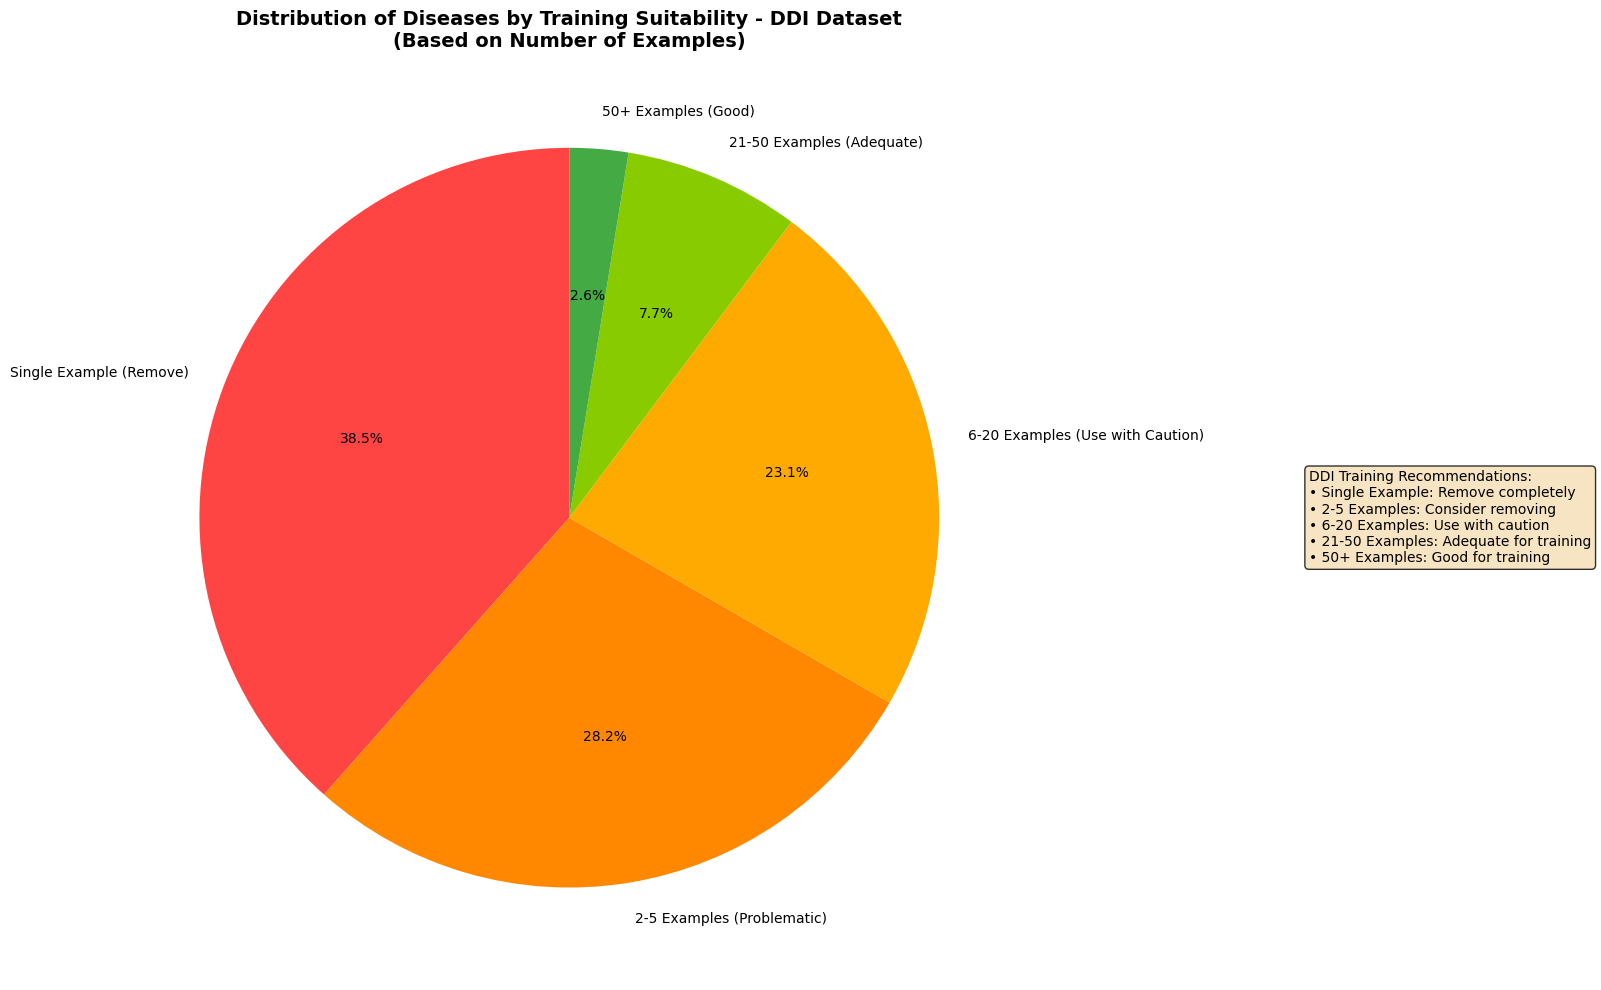

In [33]:
# Pie chart analysis for DDI dataset
plt.figure(figsize=(15, 10))

# Create categories for DDI visualization
categories_ddi = {
    'Single Example (Remove)': len(ddi_disease_counts[ddi_disease_counts == 1]),
    '2-5 Examples (Problematic)': len(ddi_disease_counts[(ddi_disease_counts >= 2) & (ddi_disease_counts <= 5)]),
    '6-20 Examples (Use with Caution)': len(ddi_disease_counts[(ddi_disease_counts >= 6) & (ddi_disease_counts <= 20)]),
    '21-50 Examples (Adequate)': len(ddi_disease_counts[(ddi_disease_counts >= 21) & (ddi_disease_counts <= 50)]),
    '50+ Examples (Good)': len(ddi_disease_counts[ddi_disease_counts > 50])
}

# Create pie chart for DDI
colors = ['#ff4444', '#ff8800', '#ffaa00', '#88cc00', '#44aa44']
plt.pie(categories_ddi.values(), labels=categories_ddi.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribution of Diseases by Training Suitability - DDI Dataset\n(Based on Number of Examples)', fontsize=14, fontweight='bold')

# Add text box with recommendations
textstr = '''DDI Training Recommendations:
• Single Example: Remove completely
• 2-5 Examples: Consider removing
• 6-20 Examples: Use with caution
• 21-50 Examples: Adequate for training
• 50+ Examples: Good for training'''
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(1.3, 0.5, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', bbox=props)

plt.tight_layout()
plt.savefig('ddi_training_suitability_analysis.png', dpi=300, bbox_inches='tight')
print("\nDDI training suitability chart saved as ddi_training_suitability_analysis.png")

# Summary statistics for DDI training decisions
print(f"\n" + "="*80)
print("TRAINING DECISION SUMMARY - DDI DATASET")
print("="*80)

total_diseases_ddi = len(ddi_disease_counts)
remove_completely_ddi = len(ddi_disease_counts[ddi_disease_counts <= 1])
consider_removing_ddi = len(ddi_disease_counts[(ddi_disease_counts >= 2) & (ddi_disease_counts <= 5)])
use_with_caution_ddi = len(ddi_disease_counts[(ddi_disease_counts >= 6) & (ddi_disease_counts <= 20)])
adequate_for_training_ddi = len(ddi_disease_counts[(ddi_disease_counts >= 21) & (ddi_disease_counts <= 50)])
good_for_training_ddi = len(ddi_disease_counts[ddi_disease_counts > 50])

print(f"Total diseases in DDI dataset: {total_diseases_ddi}")
print(f"")
print(f"❌ Remove completely (≤1 example): {remove_completely_ddi} diseases ({remove_completely_ddi/total_diseases_ddi*100:.1f}%)")
print(f"⚠️  Consider removing (2-5 examples): {consider_removing_ddi} diseases ({consider_removing_ddi/total_diseases_ddi*100:.1f}%)")
print(f"⚠️  Use with caution (6-20 examples): {use_with_caution_ddi} diseases ({use_with_caution_ddi/total_diseases_ddi*100:.1f}%)")
print(f"✅ Adequate for training (21-50 examples): {adequate_for_training_ddi} diseases ({adequate_for_training_ddi/total_diseases_ddi*100:.1f}%)")
print(f"✅ Good for training (50+ examples): {good_for_training_ddi} diseases ({good_for_training_ddi/total_diseases_ddi*100:.1f}%)")

print(f"\n--- Recommended Action for DDI ---")
if remove_completely_ddi + consider_removing_ddi > total_diseases_ddi * 0.3:
    print(f"🚨 HIGH PRIORITY: {remove_completely_ddi + consider_removing_ddi} diseases ({((remove_completely_ddi + consider_removing_ddi)/total_diseases_ddi*100):.1f}%) should be removed/considered for removal")
    print(f"   This represents a significant portion of your dataset that may hurt model performance")
else:
    print(f"✅ MANAGEABLE: Only {remove_completely_ddi + consider_removing_ddi} diseases ({((remove_completely_ddi + consider_removing_ddi)/total_diseases_ddi*100):.1f}%) are problematic")
    print(f"   Most diseases have sufficient examples for training")



Fitzpatrick17k training suitability chart saved as fitzpatrick_training_suitability_analysis.png

TRAINING DECISION SUMMARY - FITZPATRICK17K DATASET
Total labels in Fitzpatrick17k dataset: 114

❌ Remove completely (≤1 example): 0 labels (0.0%)
⚠️  Consider removing (2-5 examples): 0 labels (0.0%)
⚠️  Use with caution (6-20 examples): 0 labels (0.0%)
✅ Adequate for training (21-50 examples): 0 labels (0.0%)
✅ Good for training (50+ examples): 114 labels (100.0%)

--- Recommended Action for Fitzpatrick17k ---
✅ MANAGEABLE: Only 0 labels (0.0%) are problematic
   Most labels have sufficient examples for training


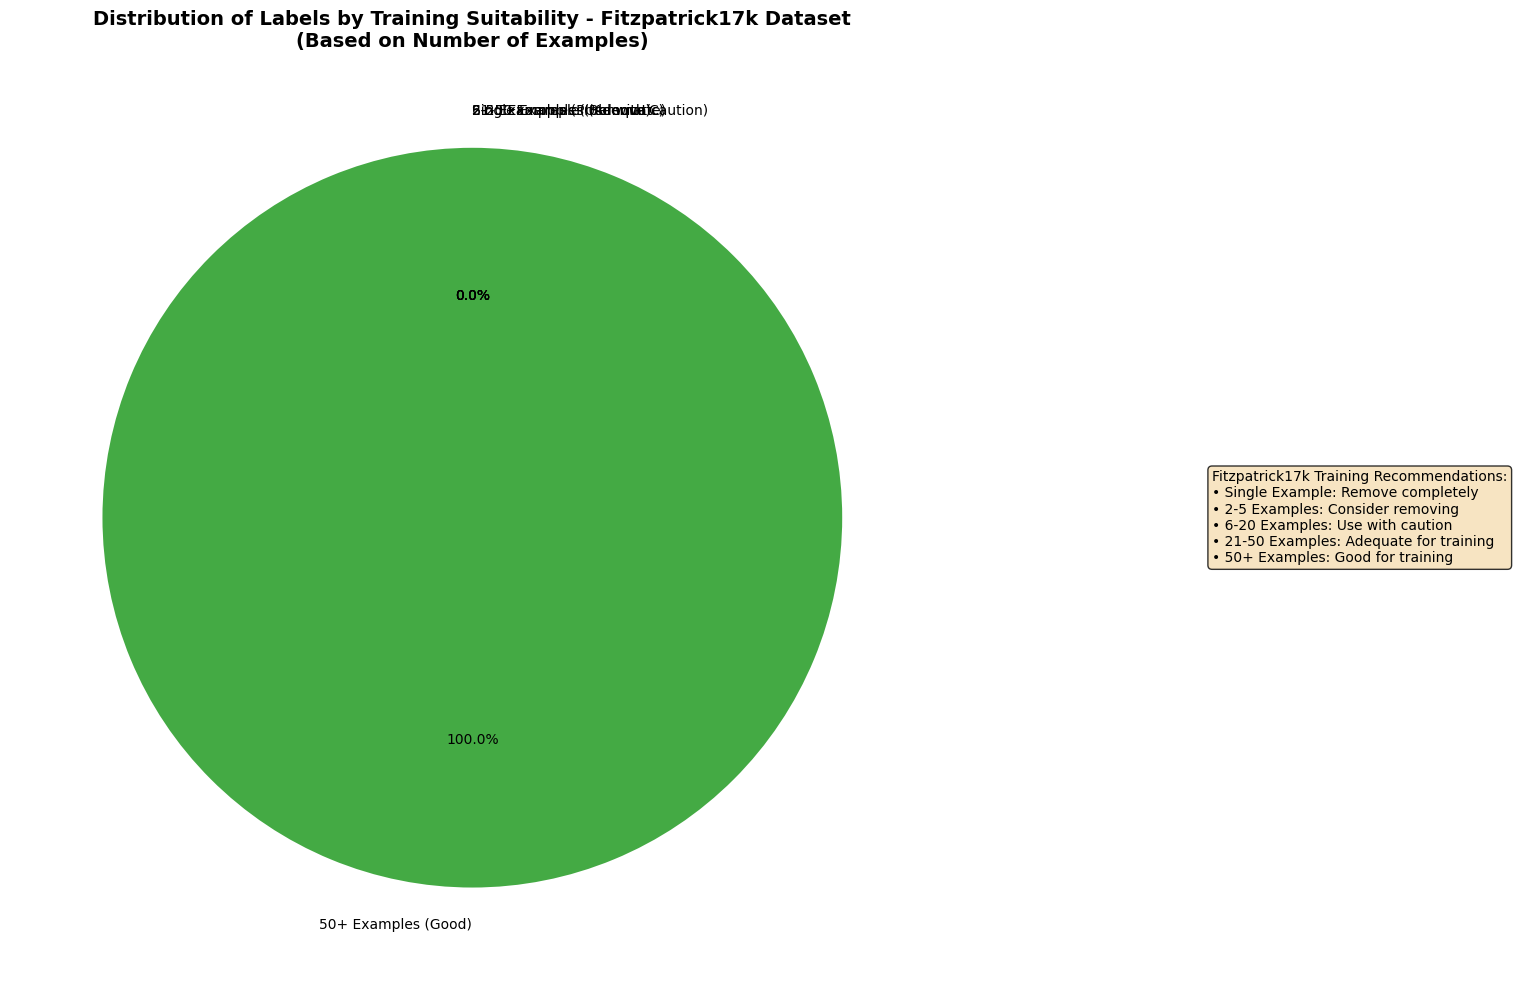

In [34]:
# Pie chart analysis for Fitzpatrick17k dataset
plt.figure(figsize=(15, 10))

# Create categories for Fitzpatrick17k visualization
categories_fitz = {
    'Single Example (Remove)': len(fitz_label_counts[fitz_label_counts == 1]),
    '2-5 Examples (Problematic)': len(fitz_label_counts[(fitz_label_counts >= 2) & (fitz_label_counts <= 5)]),
    '6-20 Examples (Use with Caution)': len(fitz_label_counts[(fitz_label_counts >= 6) & (fitz_label_counts <= 20)]),
    '21-50 Examples (Adequate)': len(fitz_label_counts[(fitz_label_counts >= 21) & (fitz_label_counts <= 50)]),
    '50+ Examples (Good)': len(fitz_label_counts[fitz_label_counts > 50])
}

# Create pie chart for Fitzpatrick17k
colors = ['#ff4444', '#ff8800', '#ffaa00', '#88cc00', '#44aa44']
plt.pie(categories_fitz.values(), labels=categories_fitz.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribution of Labels by Training Suitability - Fitzpatrick17k Dataset\n(Based on Number of Examples)', fontsize=14, fontweight='bold')

# Add text box with recommendations
textstr = '''Fitzpatrick17k Training Recommendations:
• Single Example: Remove completely
• 2-5 Examples: Consider removing
• 6-20 Examples: Use with caution
• 21-50 Examples: Adequate for training
• 50+ Examples: Good for training'''
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(1.3, 0.5, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', bbox=props)

plt.tight_layout()
plt.savefig('fitzpatrick_training_suitability_analysis.png', dpi=300, bbox_inches='tight')
print("\nFitzpatrick17k training suitability chart saved as fitzpatrick_training_suitability_analysis.png")

# Summary statistics for Fitzpatrick17k training decisions
print(f"\n" + "="*80)
print("TRAINING DECISION SUMMARY - FITZPATRICK17K DATASET")
print("="*80)

total_labels_fitz = len(fitz_label_counts)
remove_completely_fitz = len(fitz_label_counts[fitz_label_counts <= 1])
consider_removing_fitz = len(fitz_label_counts[(fitz_label_counts >= 2) & (fitz_label_counts <= 5)])
use_with_caution_fitz = len(fitz_label_counts[(fitz_label_counts >= 6) & (fitz_label_counts <= 20)])
adequate_for_training_fitz = len(fitz_label_counts[(fitz_label_counts >= 21) & (fitz_label_counts <= 50)])
good_for_training_fitz = len(fitz_label_counts[fitz_label_counts > 50])

print(f"Total labels in Fitzpatrick17k dataset: {total_labels_fitz}")
print(f"")
print(f"❌ Remove completely (≤1 example): {remove_completely_fitz} labels ({remove_completely_fitz/total_labels_fitz*100:.1f}%)")
print(f"⚠️  Consider removing (2-5 examples): {consider_removing_fitz} labels ({consider_removing_fitz/total_labels_fitz*100:.1f}%)")
print(f"⚠️  Use with caution (6-20 examples): {use_with_caution_fitz} labels ({use_with_caution_fitz/total_labels_fitz*100:.1f}%)")
print(f"✅ Adequate for training (21-50 examples): {adequate_for_training_fitz} labels ({adequate_for_training_fitz/total_labels_fitz*100:.1f}%)")
print(f"✅ Good for training (50+ examples): {good_for_training_fitz} labels ({good_for_training_fitz/total_labels_fitz*100:.1f}%)")

print(f"\n--- Recommended Action for Fitzpatrick17k ---")
if remove_completely_fitz + consider_removing_fitz > total_labels_fitz * 0.3:
    print(f"🚨 HIGH PRIORITY: {remove_completely_fitz + consider_removing_fitz} labels ({((remove_completely_fitz + consider_removing_fitz)/total_labels_fitz*100):.1f}%) should be removed/considered for removal")
    print(f"   This represents a significant portion of your dataset that may hurt model performance")
else:
    print(f"✅ MANAGEABLE: Only {remove_completely_fitz + consider_removing_fitz} labels ({((remove_completely_fitz + consider_removing_fitz)/total_labels_fitz*100):.1f}%) are problematic")
    print(f"   Most labels have sufficient examples for training")


In [ ]:
# Create CSV files for useful examples from each dataset
print("\n" + "="*80)
print("CREATING CSV FILES FOR USEFUL EXAMPLES FROM EACH DATASET")
print("="*80)

# Define minimum threshold for useful examples (21+ examples)
MIN_USEFUL_EXAMPLES = 21

# 1. DDI Dataset - Useful Examples
print(f"\n--- DDI Dataset - Useful Examples (≥{MIN_USEFUL_EXAMPLES} examples) ---")
ddi_useful_diseases = ddi_disease_counts[ddi_disease_counts >= MIN_USEFUL_EXAMPLES]
print(f"Number of useful diseases: {len(ddi_useful_diseases)}")
print(f"Total useful samples: {ddi_useful_diseases.sum()}")
print(f"Percentage of dataset: {(ddi_useful_diseases.sum() / len(ddi_df)) * 100:.1f}%")

# Create DDI useful examples DataFrame
ddi_useful_df = pd.DataFrame({
    'disease': ddi_useful_diseases.index,
    'count': ddi_useful_diseases.values,
    'dataset': 'DDI'
}).reset_index(drop=True)

# Sort by count descending
ddi_useful_df = ddi_useful_df.sort_values('count', ascending=False).reset_index(drop=True)

# Save DDI useful examples to CSV
ddi_useful_df.to_csv('ddi_useful_examples.csv', index=False)
print(f"DDI useful examples saved to: ddi_useful_examples.csv")
print(f"Top 10 useful diseases in DDI:")
for i, row in ddi_useful_df.head(10).iterrows():
    print(f"  {i+1:2d}. {row['disease']}: {row['count']} examples")


In [ ]:
# 2. Fitzpatrick17k Dataset - Useful Examples
print(f"\n--- Fitzpatrick17k Dataset - Useful Examples (≥{MIN_USEFUL_EXAMPLES} examples) ---")
fitz_useful_labels = fitz_label_counts[fitz_label_counts >= MIN_USEFUL_EXAMPLES]
print(f"Number of useful labels: {len(fitz_useful_labels)}")
print(f"Total useful samples: {fitz_useful_labels.sum()}")
print(f"Percentage of dataset: {(fitz_useful_labels.sum() / len(fitz_df)) * 100:.1f}%")

# Create Fitzpatrick17k useful examples DataFrame
fitz_useful_df = pd.DataFrame({
    'label': fitz_useful_labels.index,
    'count': fitz_useful_labels.values,
    'dataset': 'Fitzpatrick17k'
}).reset_index(drop=True)

# Sort by count descending
fitz_useful_df = fitz_useful_df.sort_values('count', ascending=False).reset_index(drop=True)

# Save Fitzpatrick17k useful examples to CSV
fitz_useful_df.to_csv('fitzpatrick_useful_examples.csv', index=False)
print(f"Fitzpatrick17k useful examples saved to: fitzpatrick_useful_examples.csv")
print(f"Top 10 useful labels in Fitzpatrick17k:")
for i, row in fitz_useful_df.head(10).iterrows():
    print(f"  {i+1:2d}. {row['label']}: {row['count']} examples")


In [ ]:
# 3. SCIN Dataset - Useful Examples
print(f"\n--- SCIN Dataset - Useful Examples (≥{MIN_USEFUL_EXAMPLES} examples) ---")
scin_useful_labels = scin_label_counts[scin_label_counts >= MIN_USEFUL_EXAMPLES]
print(f"Number of useful labels: {len(scin_useful_labels)}")
print(f"Total useful samples: {scin_useful_labels.sum()}")
print(f"Percentage of dataset: {(scin_useful_labels.sum() / len(scin_df_with_labels)) * 100:.1f}%")

# Create SCIN useful examples DataFrame
scin_useful_df = pd.DataFrame({
    'label': scin_useful_labels.index,
    'count': scin_useful_labels.values,
    'dataset': 'SCIN'
}).reset_index(drop=True)

# Sort by count descending
scin_useful_df = scin_useful_df.sort_values('count', ascending=False).reset_index(drop=True)

# Save SCIN useful examples to CSV
scin_useful_df.to_csv('scin_useful_examples.csv', index=False)
print(f"SCIN useful examples saved to: scin_useful_examples.csv")
print(f"Top 10 useful labels in SCIN:")
for i, row in scin_useful_df.head(10).iterrows():
    print(f"  {i+1:2d}. {row['label']}: {row['count']} examples")


In [ ]:
# Summary of useful examples across all datasets
print(f"\n" + "="*80)
print("SUMMARY OF USEFUL EXAMPLES ACROSS ALL DATASETS")
print("="*80)

# Create summary table
summary_data = {
    'Dataset': ['DDI', 'Fitzpatrick17k', 'SCIN'],
    'Total_Categories': [len(ddi_disease_counts), len(fitz_label_counts), len(scin_label_counts)],
    'Useful_Categories': [len(ddi_useful_diseases), len(fitz_useful_labels), len(scin_useful_labels)],
    'Total_Samples': [len(ddi_df), len(fitz_df), len(scin_df_with_labels)],
    'Useful_Samples': [ddi_useful_diseases.sum(), fitz_useful_labels.sum(), scin_useful_labels.sum()],
    'Useful_Percentage': [
        (ddi_useful_diseases.sum() / len(ddi_df)) * 100,
        (fitz_useful_labels.sum() / len(fitz_df)) * 100,
        (scin_useful_labels.sum() / len(scin_df_with_labels)) * 100
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save summary to CSV
summary_df.to_csv('useful_examples_summary.csv', index=False)
print(f"\nSummary saved to: useful_examples_summary.csv")

# Calculate total useful examples across all datasets
total_useful_categories = len(ddi_useful_diseases) + len(fitz_useful_labels) + len(scin_useful_labels)
total_useful_samples = ddi_useful_diseases.sum() + fitz_useful_labels.sum() + scin_useful_labels.sum()
total_categories = len(ddi_disease_counts) + len(fitz_label_counts) + len(scin_label_counts)
total_samples = len(ddi_df) + len(fitz_df) + len(scin_df_with_labels)

print(f"\n--- OVERALL STATISTICS ---")
print(f"Total categories across all datasets: {total_categories}")
print(f"Useful categories (≥{MIN_USEFUL_EXAMPLES} examples): {total_useful_categories}")
print(f"Useful categories percentage: {(total_useful_categories/total_categories)*100:.1f}%")
print(f"")
print(f"Total samples across all datasets: {total_samples}")
print(f"Useful samples: {total_useful_samples}")
print(f"Useful samples percentage: {(total_useful_samples/total_samples)*100:.1f}%")

print(f"\n--- FILES CREATED ---")
print(f"1. ddi_useful_examples.csv - {len(ddi_useful_diseases)} useful diseases")
print(f"2. fitzpatrick_useful_examples.csv - {len(fitz_useful_labels)} useful labels")
print(f"3. scin_useful_examples.csv - {len(scin_useful_labels)} useful labels")
print(f"4. useful_examples_summary.csv - Summary across all datasets")


In [ ]:
# Image Loading Analysis for Unified Dataset
print("\n" + "="*80)
print("IMAGE LOADING ANALYSIS FOR UNIFIED DATASET")
print("="*80)

import pandas as pd
import os
import requests
from PIL import Image
import matplotlib.pyplot as plt
from urllib.parse import urlparse
import time

# Load the unified dataset
unified_df = pd.read_csv('stage1_data/unified_dataset.csv')
print(f"Total samples in unified dataset: {len(unified_df)}")

# Analyze image path patterns
print(f"\n--- Image Path Analysis ---")
path_patterns = {}
for path in unified_df['image_path'].unique()[:100]:  # Sample first 100 unique paths
    if path.startswith('http'):
        pattern = 'URL'
    elif path.startswith('data/'):
        pattern = 'Local Data Path'
    elif path.startswith('.cache/'):
        pattern = 'Cache Path'
    else:
        pattern = 'Other'
    
    path_patterns[pattern] = path_patterns.get(pattern, 0) + 1

print("Path patterns found:")
for pattern, count in path_patterns.items():
    print(f"  {pattern}: {count} samples")

# Check if paths are URLs or local files
url_samples = unified_df[unified_df['image_path'].str.startswith('http')]
local_samples = unified_df[~unified_df['image_path'].str.startswith('http')]

print(f"\n--- Dataset Breakdown ---")
print(f"URL-based images: {len(url_samples)} samples")
print(f"Local file images: {len(local_samples)} samples")

# Check local file existence
print(f"\n--- Local File Existence Check ---")
local_file_check = []
sample_size = min(100, len(local_samples))  # Check first 100 local files

for i, path in enumerate(local_samples['image_path'].head(sample_size)):
    exists = os.path.exists(path)
    local_file_check.append(exists)
    if i < 10:  # Show first 10 results
        status = "✓ EXISTS" if exists else "✗ MISSING"
        print(f"  {path}: {status}")

local_files_exist = sum(local_file_check)
print(f"\nLocal file existence: {local_files_exist}/{sample_size} ({local_files_exist/sample_size*100:.1f}%)")


In [ ]:
# Test image loading capabilities
print(f"\n--- Image Loading Test ---")

def test_image_loading(path, max_retries=3):
    """Test if an image can be loaded"""
    try:
        if path.startswith('http'):
            # Test URL loading
            response = requests.get(path, timeout=10)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content))
                return True, f"URL loaded successfully ({img.size})"
            else:
                return False, f"URL failed with status {response.status_code}"
        else:
            # Test local file loading
            if os.path.exists(path):
                img = Image.open(path)
                return True, f"Local file loaded successfully ({img.size})"
            else:
                return False, "Local file does not exist"
    except Exception as e:
        return False, f"Loading failed: {str(e)}"

# Test a sample of images from each dataset
test_results = []
datasets_to_test = ['ddi', 'fitzpatrick', 'scin', 'dermnet']

for dataset in datasets_to_test:
    dataset_samples = unified_df[unified_df['dataset'] == dataset].head(5)
    print(f"\nTesting {dataset.upper()} dataset:")
    
    for i, (_, row) in enumerate(dataset_samples.iterrows()):
        path = row['image_path']
        success, message = test_image_loading(path)
        test_results.append({
            'dataset': dataset,
            'path': path,
            'success': success,
            'message': message
        })
        
        status = "✓" if success else "✗"
        print(f"  {status} {path}: {message}")

# Summary of test results
print(f"\n--- Test Results Summary ---")
successful_loads = sum(1 for result in test_results if result['success'])
total_tests = len(test_results)
print(f"Successful image loads: {successful_loads}/{total_tests} ({successful_loads/total_tests*100:.1f}%)")

# Group by dataset
dataset_results = {}
for result in test_results:
    dataset = result['dataset']
    if dataset not in dataset_results:
        dataset_results[dataset] = {'success': 0, 'total': 0}
    dataset_results[dataset]['total'] += 1
    if result['success']:
        dataset_results[dataset]['success'] += 1

print(f"\nResults by dataset:")
for dataset, results in dataset_results.items():
    success_rate = results['success'] / results['total'] * 100
    print(f"  {dataset}: {results['success']}/{results['total']} ({success_rate:.1f}%)")


In [ ]:
# Finetuning Library Compatibility Analysis
print(f"\n" + "="*80)
print("FINETUNING LIBRARY COMPATIBILITY ANALYSIS")
print("="*80)

# Check what finetuning libraries typically expect
print(f"\n--- Common Finetuning Library Requirements ---")
print(f"1. Transformers/Hugging Face:")
print(f"   - Expects local file paths or URLs")
print(f"   - Can handle both PIL Images and file paths")
print(f"   - Supports various image formats (PNG, JPG, etc.)")

print(f"\n2. PyTorch Lightning:")
print(f"   - Usually expects local file paths")
print(f"   - Requires custom data loaders for URLs")

print(f"\n3. FastAI:")
print(f"   - Can handle URLs directly")
print(f"   - Good for mixed local/URL datasets")

print(f"\n4. Custom Training Scripts:")
print(f"   - Depends on implementation")
print(f"   - May need preprocessing for URLs")

# Analyze current dataset structure
print(f"\n--- Current Dataset Structure Analysis ---")
print(f"Dataset columns: {list(unified_df.columns)}")
print(f"Sample data:")
print(unified_df.head(3).to_string())

# Check for URL vs local file distribution
url_count = len(unified_df[unified_df['image_path'].str.startswith('http')])
local_count = len(unified_df) - url_count

print(f"\n--- Path Type Distribution ---")
print(f"URL paths: {url_count} ({url_count/len(unified_df)*100:.1f}%)")
print(f"Local paths: {local_count} ({local_count/len(unified_df)*100:.1f}%)")

# Check if we need to download URLs
if url_count > 0:
    print(f"\n--- URL Download Recommendation ---")
    print(f"⚠️  {url_count} images are URLs that may need downloading")
    print(f"   Reasons to download:")
    print(f"   - Faster training (no network requests)")
    print(f"   - Offline training capability")
    print(f"   - Consistent data access")
    print(f"   - Better error handling")
    
    print(f"\n   Reasons to keep URLs:")
    print(f"   - Smaller dataset size")
    print(f"   - Always up-to-date images")
    print(f"   - No local storage requirements")

# Create recommendations
print(f"\n--- RECOMMENDATIONS ---")
print(f"1. For Transformers/Hugging Face:")
if url_count > 0:
    print(f"   ⚠️  Consider downloading URL images for better performance")
    print(f"   ✅ Can handle mixed local/URL paths")
else:
    print(f"   ✅ All local paths - ready for training")

print(f"\n2. For PyTorch Lightning:")
if url_count > 0:
    print(f"   ⚠️  Download URL images or create custom data loader")
else:
    print(f"   ✅ All local paths - ready for training")

print(f"\n3. For FastAI:")
print(f"   ✅ Can handle URLs directly - no changes needed")

print(f"\n4. General Recommendations:")
print(f"   - Test with a small sample first")
print(f"   - Monitor loading times during training")
print(f"   - Consider data augmentation for small datasets")
print(f"   - Ensure consistent image formats")


In [ ]:
# Create a script to download URL images if needed
print(f"\n" + "="*80)
print("URL DOWNLOAD SCRIPT GENERATION")
print("="*80)

# Check if there are URLs to download
url_samples = unified_df[unified_df['image_path'].str.startswith('http')]
if len(url_samples) > 0:
    print(f"Found {len(url_samples)} URL-based images")
    print(f"Creating download script...")
    
    # Create download script
    download_script = '''
# URL Image Download Script
import pandas as pd
import requests
import os
from PIL import Image
from io import BytesIO
import time
from pathlib import Path

def download_url_images(csv_path, output_dir="downloaded_images"):
    """Download all URL images and update the CSV with local paths"""
    
    # Load the dataset
    df = pd.read_csv(csv_path)
    
    # Create output directory
    Path(output_dir).mkdir(exist_ok=True)
    
    # Filter URL samples
    url_samples = df[df['image_path'].str.startswith('http')]
    print(f"Found {len(url_samples)} URL images to download")
    
    downloaded_count = 0
    failed_count = 0
    
    for idx, row in url_samples.iterrows():
        url = row['image_path']
        dataset = row['dataset']
        disease = row['disease']
        
        # Create filename
        filename = f"{dataset}_{disease}_{idx}.jpg"
        local_path = os.path.join(output_dir, filename)
        
        try:
            # Download image
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            
            # Save image
            with open(local_path, 'wb') as f:
                f.write(response.content)
            
            # Update the dataframe
            df.at[idx, 'image_path'] = local_path
            downloaded_count += 1
            
            if downloaded_count % 100 == 0:
                print(f"Downloaded {downloaded_count} images...")
                
        except Exception as e:
            print(f"Failed to download {url}: {e}")
            failed_count += 1
    
    # Save updated dataset
    output_csv = csv_path.replace('.csv', '_with_downloaded_images.csv')
    df.to_csv(output_csv, index=False)
    
    print(f"\\nDownload complete!")
    print(f"Downloaded: {downloaded_count}")
    print(f"Failed: {failed_count}")
    print(f"Updated dataset saved to: {output_csv}")
    
    return df

# Usage example:
# download_url_images('stage1_data/unified_dataset.csv')
'''
    
    # Save the script
    with open('download_url_images.py', 'w') as f:
        f.write(download_script)
    
    print(f"Download script saved to: download_url_images.py")
    print(f"To use: python download_url_images.py")
    
else:
    print(f"No URL images found - all images are local files")
    print(f"No download script needed")

# Create a dataset validation script
validation_script = '''
# Dataset Validation Script
import pandas as pd
import os
from PIL import Image

def validate_dataset(csv_path):
    """Validate that all images in the dataset can be loaded"""
    
    df = pd.read_csv(csv_path)
    print(f"Validating {len(df)} images...")
    
    valid_count = 0
    invalid_count = 0
    invalid_samples = []
    
    for idx, row in df.iterrows():
        path = row['image_path']
        
        try:
            if os.path.exists(path):
                img = Image.open(path)
                img.verify()  # Verify it's a valid image
                valid_count += 1
            else:
                invalid_count += 1
                invalid_samples.append((idx, path, "File not found"))
                
        except Exception as e:
            invalid_count += 1
            invalid_samples.append((idx, path, str(e)))
        
        if (idx + 1) % 1000 == 0:
            print(f"Validated {idx + 1} images...")
    
    print(f"\\nValidation complete!")
    print(f"Valid images: {valid_count}")
    print(f"Invalid images: {invalid_count}")
    
    if invalid_samples:
        print(f"\\nFirst 10 invalid samples:")
        for idx, path, error in invalid_samples[:10]:
            print(f"  Row {idx}: {path} - {error}")
    
    return valid_count, invalid_count, invalid_samples

# Usage example:
# validate_dataset('stage1_data/unified_dataset.csv')
'''

# Save validation script
with open('validate_dataset.py', 'w') as f:
    f.write(validation_script)

print(f"\\nValidation script saved to: validate_dataset.py")
print(f"To use: python validate_dataset.py")


In [ ]:
# Qwen2-VL-Finetune Compatibility Analysis
print("\n" + "="*80)
print("QWEN2-VL-FINETUNE COMPATIBILITY ANALYSIS")
print("="*80)

# Check Qwen2-VL specific requirements
print(f"\n--- Qwen2-VL-Finetune Requirements ---")
print(f"1. Dataset Format:")
print(f"   - JSON format with 'id', 'image', 'conversations' fields")
print(f"   - Image field can be local path or URL")
print(f"   - Conversations field with 'from' and 'value'")

print(f"\n2. Image Requirements:")
print(f"   - Supported formats: BMP, JPEG, PNG, TIFF, WEBP")
print(f"   - Max file size: 10MB per image")
print(f"   - Max pixels: 12M for qwen-vl-max-0809, 1M for others")
print(f"   - Recommended size: 1024x1024 for most models")

print(f"\n3. Current Dataset Analysis:")
print(f"   - Format: CSV with 'image_path', 'disease', 'dataset', 'split'")
print(f"   - Need to convert to Qwen2-VL format")

# Analyze current dataset for Qwen2-VL compatibility
print(f"\n--- Current Dataset Compatibility Check ---")

# Check image formats
image_extensions = {}
for path in unified_df['image_path'].head(1000):
    if '.' in path:
        ext = path.split('.')[-1].lower()
        image_extensions[ext] = image_extensions.get(ext, 0) + 1

print(f"Image formats found:")
for ext, count in sorted(image_extensions.items()):
    print(f"  .{ext}: {count} files")

# Check if formats are supported
supported_formats = ['bmp', 'jpeg', 'jpg', 'png', 'tiff', 'webp']
unsupported_formats = [ext for ext in image_extensions.keys() if ext not in supported_formats]

if unsupported_formats:
    print(f"\n⚠️  Unsupported formats found: {unsupported_formats}")
else:
    print(f"\n✅ All image formats are supported by Qwen2-VL")

# Check image sizes (sample)
print(f"\n--- Image Size Analysis (Sample) ---")
size_analysis = {'valid': 0, 'too_large': 0, 'error': 0}
sample_size = min(50, len(unified_df))

for i, path in enumerate(unified_df['image_path'].head(sample_size)):
    try:
        if os.path.exists(path):
            file_size = os.path.getsize(path)
            if file_size > 10 * 1024 * 1024:  # 10MB
                size_analysis['too_large'] += 1
            else:
                size_analysis['valid'] += 1
        else:
            size_analysis['error'] += 1
    except:
        size_analysis['error'] += 1

print(f"Size analysis (sample of {sample_size}):")
print(f"  Valid size (<10MB): {size_analysis['valid']}")
print(f"  Too large (>10MB): {size_analysis['too_large']}")
print(f"  Error accessing: {size_analysis['error']}")

if size_analysis['too_large'] > 0:
    print(f"\n⚠️  Some images exceed 10MB limit")
else:
    print(f"\n✅ All sampled images are within size limits")


In [ ]:
# Create Qwen2-VL dataset conversion script
print(f"\n" + "="*80)
print("CREATING QWEN2-VL DATASET CONVERSION SCRIPT")
print("="*80)

# Create the conversion script
qwen_conversion_script = '''
# Qwen2-VL Dataset Conversion Script
import pandas as pd
import json
import os
from pathlib import Path

def convert_to_qwen2vl_format(csv_path, output_path="qwen2vl_dataset.json"):
    """Convert CSV dataset to Qwen2-VL format"""
    
    # Load the dataset
    df = pd.read_csv(csv_path)
    print(f"Converting {len(df)} samples to Qwen2-VL format...")
    
    qwen_data = []
    
    for idx, row in df.iterrows():
        # Create Qwen2-VL format entry
        entry = {
            "id": f"dermatology_{idx:06d}",
            "image": row['image_path'],
            "conversations": [
                {
                    "from": "human",
                    "value": f"<image>\\nWhat skin condition is shown in this image?"
                },
                {
                    "from": "gpt", 
                    "value": f"This image shows {row['disease']}."
                }
            ]
        }
        
        qwen_data.append(entry)
        
        if (idx + 1) % 1000 == 0:
            print(f"Converted {idx + 1} samples...")
    
    # Save as JSON
    with open(output_path, 'w') as f:
        json.dump(qwen_data, f, indent=2)
    
    print(f"\\nConversion complete!")
    print(f"Saved {len(qwen_data)} samples to {output_path}")
    
    return qwen_data

def create_train_val_split(qwen_data, train_ratio=0.8):
    """Split dataset into train and validation sets"""
    
    # Filter by split if available
    train_data = [item for item in qwen_data if item['id'].endswith('_train')]
    val_data = [item for item in qwen_data if item['id'].endswith('_val')]
    
    if not train_data and not val_data:
        # If no split info, create random split
        import random
        random.shuffle(qwen_data)
        split_idx = int(len(qwen_data) * train_ratio)
        train_data = qwen_data[:split_idx]
        val_data = qwen_data[split_idx:]
    
    # Save train and val files
    with open('qwen2vl_train.json', 'w') as f:
        json.dump(train_data, f, indent=2)
    
    with open('qwen2vl_val.json', 'w') as f:
        json.dump(val_data, f, indent=2)
    
    print(f"\\nSplit complete!")
    print(f"Train samples: {len(train_data)}")
    print(f"Validation samples: {len(val_data)}")
    
    return train_data, val_data

# Usage example:
# qwen_data = convert_to_qwen2vl_format('stage1_data/unified_dataset.csv')
# train_data, val_data = create_train_val_split(qwen_data)
'''

# Save the conversion script
with open('convert_to_qwen2vl.py', 'w') as f:
    f.write(qwen_conversion_script)

print(f"Qwen2-VL conversion script saved to: convert_to_qwen2vl.py")

# Create Qwen2-VL specific validation script
qwen_validation_script = '''
# Qwen2-VL Dataset Validation Script
import pandas as pd
import json
import os
from PIL import Image

def validate_qwen2vl_dataset(json_path):
    """Validate Qwen2-VL dataset format and image accessibility"""
    
    # Load JSON dataset
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    print(f"Validating {len(data)} samples...")
    
    valid_count = 0
    invalid_count = 0
    invalid_samples = []
    
    for item in data:
        try:
            # Check required fields
            if 'id' not in item or 'image' not in item or 'conversations' not in item:
                invalid_count += 1
                invalid_samples.append((item.get('id', 'unknown'), "Missing required fields"))
                continue
            
            # Check image accessibility
            image_path = item['image']
            if os.path.exists(image_path):
                # Check image format and size
                img = Image.open(image_path)
                img.verify()
                
                # Check file size
                file_size = os.path.getsize(image_path)
                if file_size > 10 * 1024 * 1024:  # 10MB
                    invalid_count += 1
                    invalid_samples.append((item['id'], f"Image too large: {file_size/1024/1024:.1f}MB"))
                    continue
                
                # Check pixel count
                img = Image.open(image_path)
                pixel_count = img.size[0] * img.size[1]
                if pixel_count > 12 * 1000 * 1000:  # 12M pixels
                    invalid_count += 1
                    invalid_samples.append((item['id'], f"Too many pixels: {pixel_count:,}"))
                    continue
                
                valid_count += 1
            else:
                invalid_count += 1
                invalid_samples.append((item['id'], f"Image not found: {image_path}"))
                
        except Exception as e:
            invalid_count += 1
            invalid_samples.append((item.get('id', 'unknown'), f"Error: {str(e)}"))
    
    print(f"\\nValidation complete!")
    print(f"Valid samples: {valid_count}")
    print(f"Invalid samples: {invalid_count}")
    
    if invalid_samples:
        print(f"\\nFirst 10 invalid samples:")
        for sample_id, error in invalid_samples[:10]:
            print(f"  {sample_id}: {error}")
    
    return valid_count, invalid_count, invalid_samples

# Usage example:
# validate_qwen2vl_dataset('qwen2vl_dataset.json')
'''

# Save validation script
with open('validate_qwen2vl.py', 'w') as f:
    f.write(qwen_validation_script)

print(f"Qwen2-VL validation script saved to: validate_qwen2vl.py")


In [ ]:
# Create comprehensive Qwen2-VL setup script
print(f"\n" + "="*80)
print("CREATING COMPREHENSIVE QWEN2-VL SETUP SCRIPT")
print("="*80)

# Create a comprehensive setup script
setup_script = '''
# Comprehensive Qwen2-VL Setup Script
import pandas as pd
import json
import os
import requests
from PIL import Image
from pathlib import Path
import time

def setup_qwen2vl_dataset(csv_path="stage1_data/unified_dataset.csv"):
    """Complete setup for Qwen2-VL finetuning"""
    
    print("="*60)
    print("QWEN2-VL DATASET SETUP")
    print("="*60)
    
    # Step 1: Load and analyze dataset
    print("\\nStep 1: Loading dataset...")
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} samples")
    
    # Step 2: Check image accessibility
    print("\\nStep 2: Checking image accessibility...")
    url_samples = df[df['image_path'].str.startswith('http')]
    local_samples = df[~df['image_path'].str.startswith('http')]
    
    print(f"URL images: {len(url_samples)}")
    print(f"Local images: {len(local_samples)}")
    
    # Step 3: Download URL images if needed
    if len(url_samples) > 0:
        print(f"\\nStep 3: Downloading URL images...")
        download_url_images(df, url_samples)
    
    # Step 4: Convert to Qwen2-VL format
    print(f"\\nStep 4: Converting to Qwen2-VL format...")
    qwen_data = convert_to_qwen2vl_format(df)
    
    # Step 5: Create train/val split
    print(f"\\nStep 5: Creating train/validation split...")
    train_data, val_data = create_train_val_split(qwen_data, df)
    
    # Step 6: Validate final dataset
    print(f"\\nStep 6: Validating final dataset...")
    validate_final_dataset(train_data, val_data)
    
    print(f"\\n" + "="*60)
    print("SETUP COMPLETE!")
    print("="*60)
    print(f"Files created:")
    print(f"- qwen2vl_train.json ({len(train_data)} samples)")
    print(f"- qwen2vl_val.json ({len(val_data)} samples)")
    print(f"- downloaded_images/ (if URLs were downloaded)")
    
    return train_data, val_data

def download_url_images(df, url_samples):
    """Download URL images to local storage"""
    
    output_dir = "downloaded_images"
    Path(output_dir).mkdir(exist_ok=True)
    
    downloaded_count = 0
    failed_count = 0
    
    for idx, row in url_samples.iterrows():
        url = row['image_path']
        dataset = row['dataset']
        disease = row['disease']
        
        # Create filename
        filename = f"{dataset}_{disease}_{idx}.jpg"
        local_path = os.path.join(output_dir, filename)
        
        try:
            # Download image
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            
            # Save image
            with open(local_path, 'wb') as f:
                f.write(response.content)
            
            # Update the dataframe
            df.at[idx, 'image_path'] = local_path
            downloaded_count += 1
            
            if downloaded_count % 100 == 0:
                print(f"Downloaded {downloaded_count} images...")
                
        except Exception as e:
            print(f"Failed to download {url}: {e}")
            failed_count += 1
    
    print(f"Download complete: {downloaded_count} success, {failed_count} failed")
    return df

def convert_to_qwen2vl_format(df):
    """Convert DataFrame to Qwen2-VL format"""
    
    qwen_data = []
    
    for idx, row in df.iterrows():
        entry = {
            "id": f"dermatology_{idx:06d}",
            "image": row['image_path'],
            "conversations": [
                {
                    "from": "human",
                    "value": f"<image>\\nWhat skin condition is shown in this image?"
                },
                {
                    "from": "gpt", 
                    "value": f"This image shows {row['disease']}."
                }
            ]
        }
        qwen_data.append(entry)
    
    return qwen_data

def create_train_val_split(qwen_data, df):
    """Create train/validation split based on original split column"""
    
    train_data = []
    val_data = []
    
    for i, item in enumerate(qwen_data):
        original_split = df.iloc[i]['split']
        if original_split == 'train':
            train_data.append(item)
        else:
            val_data.append(item)
    
    # Save files
    with open('qwen2vl_train.json', 'w') as f:
        json.dump(train_data, f, indent=2)
    
    with open('qwen2vl_val.json', 'w') as f:
        json.dump(val_data, f, indent=2)
    
    return train_data, val_data

def validate_final_dataset(train_data, val_data):
    """Validate the final dataset"""
    
    print(f"Validating train set ({len(train_data)} samples)...")
    train_valid = validate_samples(train_data)
    
    print(f"Validating validation set ({len(val_data)} samples)...")
    val_valid = validate_samples(val_data)
    
    print(f"\\nFinal validation results:")
    print(f"Train set: {train_valid}/{len(train_data)} valid")
    print(f"Validation set: {val_valid}/{len(val_data)} valid")
    
    return train_valid, val_valid

def validate_samples(samples):
    """Validate a list of samples"""
    
    valid_count = 0
    
    for item in samples:
        try:
            image_path = item['image']
            if os.path.exists(image_path):
                img = Image.open(image_path)
                img.verify()
                valid_count += 1
        except:
            pass
    
    return valid_count

# Run the setup
if __name__ == "__main__":
    train_data, val_data = setup_qwen2vl_dataset()
'''

# Save the setup script
with open('setup_qwen2vl.py', 'w') as f:
    f.write(setup_script)

print(f"Comprehensive setup script saved to: setup_qwen2vl.py")

# Create a simple usage guide
usage_guide = '''
# Qwen2-VL Dataset Setup Guide

## Quick Start:
```bash
python setup_qwen2vl.py
```

## Manual Steps:
1. Convert dataset: `python convert_to_qwen2vl.py`
2. Validate dataset: `python validate_qwen2vl.py`
3. Download URLs (if needed): `python download_url_images.py`

## Files Created:
- `qwen2vl_train.json` - Training dataset
- `qwen2vl_val.json` - Validation dataset
- `downloaded_images/` - Downloaded URL images

## Qwen2-VL Training:
```bash
# Example training command (adjust paths as needed)
python -m qwen2vl_finetune.train \\
    --model_name_or_path Qwen/Qwen2-VL-7B-Instruct \\
    --train_data_path qwen2vl_train.json \\
    --eval_data_path qwen2vl_val.json \\
    --output_dir ./output \\
    --num_train_epochs 3 \\
    --per_device_train_batch_size 1 \\
    --per_device_eval_batch_size 1 \\
    --gradient_accumulation_steps 8 \\
    --learning_rate 2e-5 \\
    --warmup_ratio 0.03 \\
    --lr_scheduler_type cosine \\
    --logging_steps 1 \\
    --save_steps 500 \\
    --save_total_limit 2 \\
    --evaluation_strategy steps \\
    --eval_steps 500 \\
    --save_strategy steps \\
    --bf16 True \\
    --tf32 True \\
    --gradient_checkpointing True \\
    --dataloader_num_workers 0 \\
    --remove_unused_columns False \\
    --report_to none
```

## Dataset Format:
Each sample should have:
- `id`: Unique identifier
- `image`: Path to image file
- `conversations`: List of conversation turns

Example:
```json
{
  "id": "dermatology_000001",
  "image": "data/ddidiversedermatologyimages/000001.png",
  "conversations": [
    {
      "from": "human",
      "value": "<image>\\nWhat skin condition is shown in this image?"
    },
    {
      "from": "gpt",
      "value": "This image shows melanoma-in-situ."
    }
  ]
}
```
'''

# Save usage guide
with open('QWEN2VL_SETUP_GUIDE.md', 'w') as f:
    f.write(usage_guide)

print(f"Usage guide saved to: QWEN2VL_SETUP_GUIDE.md")

print(f"\n--- FILES CREATED ---")
print(f"1. convert_to_qwen2vl.py - Convert CSV to Qwen2-VL format")
print(f"2. validate_qwen2vl.py - Validate Qwen2-VL dataset")
print(f"3. setup_qwen2vl.py - Complete setup script")
print(f"4. QWEN2VL_SETUP_GUIDE.md - Usage guide")
print(f"5. download_url_images.py - Download URL images")
print(f"6. validate_dataset.py - General dataset validation")
